## **Análise Estratégica do E-Commerce Brasileiro (Olist 2016-2018)**


Este trabalho integra o Tech Challenge da Pós-Tech em Data Analytics da FIAP e corresponde à avaliação da Fase I da pós-graduação. O desafio central é a construção de um relatório executivo direcionado a investidores e acionistas do setor de e-commerce, utilizando como base o [Brazilian E-Commerce Public Dataset da Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce). A equipe responsável pelo desenvolvimento é formada por:


*   Allan Diniz      
*   Bruna Andrade
*   Carlos Freitas   
*   Evellyn Machado  
*   Maycon Nunes     


## **1. Contextualização**

No dinâmico cenário do e-commerce brasileiro, a capacidade de transformar grandes volumes de dados transacionais em inteligência estratégica é um fator decisivo para sustentar o crescimento do negócio. Para ecossistemas como o da Olist, que conectam milhares de vendedores a múltiplos marketplaces, compreender padrões de consumo e identificar gargalos operacionais é essencial para mitigar riscos e capturar oportunidades de expansão.

Nesse contexto, variações na eficiência logística ou na satisfação do cliente podem impactar diretamente a reputação da plataforma e seus resultados financeiros, tornando a análise de dados um elemento central na tomada de decisão.

O objetivo deste estudo é analisar o desempenho comercial e operacional da Olist no período de 2016 a 2018. A partir de uma abordagem multidimensional, integrando dados de vendas, logística e comportamento do consumidor. Buscamos gerar uma visão clara sobre a saúde do negócio.

Com base nos indicadores analisados, este relatório apresenta insights e recomendações estratégicas voltadas a apoiar a tomada de decisão de investidores e lideranças executivas.

## **2. Perguntas de Negócio**



Para orientar a análise e garantir uma abordagem estruturada, este estudo foi guiado por três perguntas-chave:

* **Qual foi a evolução da receita da plataforma e quais fatores influenciaram seu desempenho?**

* **Como a performance logística acompanhou a evolução do negócio e qual seu impacto na eficiência operacional?**

* **Como a experiência do cliente evoluiu ao longo do tempo e quais fatores influenciam sua satisfação?**

Essas perguntas estruturam a análise em três dimensões fundamentais do negócio: crescimento, eficiência operacional e experiência do cliente. Permitindo uma visão integrada do desempenho da plataforma.

## **3. Base de Dados e Metodologia**
O conjunto de dados é composto por informações reais e anonimizadas de aproximadamente 100 mil pedidos realizados entre 2016 e 2018.


A análise será estruturada através da integração de tabelas de:


*   Transações: Pedidos, itens e pagamentos
*   Logística: Datas de entrega, geolocalização e status
*   Sentimento: Avaliações e comentários dos clientes (Customer Reviews).# Nova seção

## **4. Principais Indicadores de Desempenho (KPIs)**



Com base nas perguntas de negócio, foram definidos KPIs organizados em três dimensões: receita, logística e satisfação do cliente. Esses indicadores permitem avaliar de forma integrada o desempenho do negócio, conectando crescimento, eficiência operacional e experiência do consumidor.

### **4.1 KPIs — Receita**

Objetivo: Identificar os pilares financeiros que sustentam o negócio e se o crescimento é orgânico ou dependente de nichos específicos.



1.   KPI 1: Receita total ao longo do tempo | Insight: crescimento, sazonalidade
2.   KPI 2: Ticket médio | Insight: cliente compra mais caro ou mais barato? Mudança ao longo do tempo
3.   KPI 3: Receita por categoria | Insight: Quais categorias sustentam o negócio?





### **4.2 KPIs — Logística**

Objetivo: medir eficiência operacional



1.   KPI 1: Tempo médio de entrega | Insight: eficiência logística geral
2.   KPI 2: % de pedidos com atraso | Insight: qualidade do SLA
3.   KPI 3: Tempo de entrega por estado | Insight: gargalos regionais


### **4.3 KPIs — Satisfação**

Objetivo: entender experiência do cliente


1.   KPI 1: Nota média | Insight: qualidade geral do serviço
2.   KPI 2: % de avaliações positivas | Insight: percepção do cliente
3.   KPI 3: Impacto do atraso na avaliação | Insight: atraso → piora satisfação?





## **5. Importando as Bibliotecas e os Datasets**







In [1]:
#Libs

import pandas as pd
import numpy as np

#libs gráficas
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

#Avisos
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importando as bases de dados
df_clientes = pd.read_csv('/content/olist_customers_dataset.csv')
df_pedidos = pd.read_csv('/content/olist_orders_dataset.csv')
df_itens_pedido = pd.read_csv('/content/olist_order_items_dataset.csv')
df_pagamentos = pd.read_csv('/content/olist_order_payments_dataset.csv')
df_avaliacoes = pd.read_csv('/content/olist_order_reviews_dataset.csv')
df_produtos = pd.read_csv('/content/olist_products_dataset.csv')
df_vendedores = pd.read_csv('/content/olist_sellers_dataset.csv')
df_geolocalizacao = pd.read_csv('/content/olist_geolocation_dataset.csv')
df_traducao_categorias = pd.read_csv('/content/product_category_name_translation.csv')

## **6. Tratamento e Limpeza dos dados**

### **6.1 Funções**

#### **Função de Análise Básica**

Criei esta função para padronizar a análise exploratória inicial das bases de dados.
O objetivo é evitar repetição de código e facilitar o diagnóstico de problemas
como valores nulos, duplicados, colunas constantes e tipos de dados.


In [3]:
def analise_basica(df, nome_base="Base de dados", mostrar_head=True):
    """
    Função de análise exploratória básica de um DataFrame para diagnóstico inicial de limpeza.

    Parâmetros:
    df (pd.DataFrame): DataFrame a ser analisado.
    nome_base (str): Nome da base de dados (opcional).
    mostrar_head (bool): Se True, mostra as primeiras linhas.
    """

    print(f"\n--- Análise da {nome_base} ---\n")

    # Primeiras linhas
    if mostrar_head:
        print("Primeiras linhas:")
        print(df.head(), "\n")

    # Tamanho da base
    print(f"Tamanho da base (Linhas, Colunas): {df.shape}\n")

    # Tipos de dados
    print("Tipos de dados:")
    print(df.dtypes, "\n")

    # Valores nulos
    print("Valores nulos por coluna:")
    print(df.isnull().sum(), "\n")
    print(f"Total de valores nulos: {df.isnull().sum().sum()}\n")

    # Valores únicos
    print("Valores únicos por coluna:")
    print(df.nunique(), "\n")

    # Colunas constantes
    constantes = [col for col in df.columns if df[col].nunique() == 1]
    print(f"Colunas com apenas um valor único: {constantes}\n")

    # Valores duplicados
    duplicados = df.duplicated().sum()
    print(f"Quantidade de dados duplicados: {duplicados}\n")

    # Colunas categóricas
    print("Colunas categóricas (object):")
    print(df.select_dtypes(include="object").columns, "\n")

    # Resumo estatístico
    print("Resumo estatístico das colunas numéricas:")
    print(df.describe(), "\n")

#### **Função de Correção de CEPs**

Criei a função `corrigir_ceps()` para padronizar colunas de CEP em diferentes bases de dados.  
Durante a investigação, identifiquei que os CEPs estavam armazenados como números inteiros (`int64`), o que é inadequado, pois remove zeros à esquerda e trata o CEP como variável numérica, quando na verdade ele deve ser considerado um identificador categórico.

A função realiza os seguintes passos:
- Converte a coluna de CEP para o tipo `string` (`object`).
- Explora a distribuição de dígitos para verificar inconsistências.
- Identifica e quantifica registros com menos dígitos do que o padrão definido.
- Corrige os valores, preenchendo com zeros à esquerda até atingir o tamanho desejado (por padrão, 5 dígitos).
- Retorna o DataFrame com a coluna de CEP padronizada.


In [4]:
def corrigir_ceps(df, coluna_cep):
    """
    Função para corrigir e padronizar CEPs em uma coluna de DataFrame.

    Parâmetros:
    df (pd.DataFrame): DataFrame que contém a coluna de CEP.
    coluna_cep (str): Nome da coluna que contém os CEPs.

    Retorna:
    pd.DataFrame: DataFrame com a coluna de CEP corrigida e validada.
    """

    # 1. Converter para string
    df[coluna_cep] = df[coluna_cep].astype(str)

    # 2. Explorar a coluna: verificar quantos dígitos cada CEP possui
    print("Distribuição de dígitos na coluna de CEP:")
    print(df[coluna_cep].str.len().value_counts(), "\n")

    # 3. Identificar os casos problemáticos
    print("Exemplos de CEPs com menos dígitos:")
    print(df[df[coluna_cep].str.len() < 5][coluna_cep].head(), "\n")

    # 4. Quantificar o problema
    faltando_zeros = (df[coluna_cep].str.len() < 5).sum()
    print(f"Quantidade de CEPs com zeros faltando: {faltando_zeros}\n")

    # 5. Corrigir o problema: padronizar todos os CEPs para 5 dígitos
    df[coluna_cep] = df[coluna_cep].str.zfill(5)
    print("Correção aplicada: todos os CEPs agora têm 5 dígitos.\n")

    # 6. Validação: garantir que todos os CEPs tenham 5 dígitos e sejam numéricos
    valido = df[coluna_cep].str.len().eq(5).all() and df[coluna_cep].str.isnumeric().all()

    if valido:
        print("Correção e validação concluídas: todos os CEPs possuem 5 dígitos e são numéricos.\n")
    else:
        print("Atenção: ainda existem CEPs fora do padrão.\n")

    return df

#### **Função de Correção de Cidades**

Criei a função `padronizar_cidades()` para padronizar colunas de cidades em diferentes bases de dados.  
Durante a investigação, identifiquei que os nomes das cidades estavam armazenados em letras minúsculas e sem acentuação.
Embora a análise tenha mostrado que não existem registros com `_`, manter essa verificação é importante para garantir consistência em diferentes bases ou versões futuras dos dados.

A função realiza os seguintes passos:

- Converte a coluna de cidades para o tipo string (object).  
- Explora a coluna para verificar número de valores únicos e possíveis inconsistências.  
- Identifica e quantifica registros com letras minúsculas e com `_` no nome.  
- Corrige os valores, substituindo `_` por espaço e aplicando `.title()` para padronizar a capitalização.  
- Retorna o DataFrame com a coluna de cidades padronizada.

In [5]:
def padronizar_cidades(df, coluna_cidade):
    """
    Função para padronizar nomes de cidades em uma coluna de DataFrame.

    Parâmetros:
    df (pd.DataFrame): DataFrame que contém a coluna de cidades.
    coluna_cidade (str): Nome da coluna que contém os nomes das cidades.

    Retorna:
    pd.DataFrame: DataFrame com a coluna de cidades padronizada.
    """

    # 1. Converter para string
    df[coluna_cidade] = df[coluna_cidade].astype(str)

    # 2. Explorar a coluna: verificar número de valores únicos
    num_cidades = df[coluna_cidade].nunique()
    print(f"A coluna {coluna_cidade} apresenta {num_cidades} valores únicos.\n")

    # 3. Identificar problemas: minúsculas e underscores
    minusc = df[coluna_cidade].str.islower().sum()
    com_underscore = df[coluna_cidade].str.contains('_').sum()
    print(f"Quantidade de cidades em minúsculo: {minusc}")
    print(f"Quantidade de cidades com '_' no nome: {com_underscore}\n")

    # 4. Corrigir o problema: substituir '_' por espaço e aplicar .title()
    df[coluna_cidade] = (
        df[coluna_cidade]
        .str.replace('_', ' ')
        .str.title()
    )
    print("Correção aplicada: nomes de cidades padronizados para melhor leitura.\n")

    # 5. Validar a correção: conferir alguns exemplos
    print(df[coluna_cidade].head(10))

    return df

#### **Função de Correção de Datas**

Criei a função `corrigir_datas()` para padronizar colunas de datas em diferentes bases de dados.  
Durante a investigação, identifiquei que todas as colunas de datas estavam armazenadas como strings (`object`), o que é inadequado para análises temporais, pois impede cálculos de diferença entre datas, ordenações cronológicas e manipulações diretas em gráficos.

A função realiza os seguintes passos:

- Converte as colunas de datas para o tipo `datetime`.  
- Explora os tipos de dados para verificar se a conversão foi aplicada corretamente.  
- Identifica e trata valores inválidos ou nulos, quando necessário.  
- Retorna o DataFrame com as colunas de datas padronizadas, prontas para análises temporais.

In [6]:
def corrigir_datas(df, colunas_datas):
    """
    Função para converter colunas de datas de string (object) para datetime em um DataFrame.

    Parâmetros:
    df (pd.DataFrame): DataFrame que contém as colunas de datas.
    colunas_datas (str ou list): Nome ou lista de nomes das colunas de datas.

    Retorna:
    pd.DataFrame: DataFrame com as colunas de datas convertidas para datetime.
    """

    # Garante que colunas_datas seja sempre uma lista
    if isinstance(colunas_datas, str):
        colunas_datas = [colunas_datas]

    # Converte cada coluna diretamente (vetorizado, sem apply)
    for col in colunas_datas:
        df[col] = pd.to_datetime(df[col], errors='coerce')

    # Valida a conversão
    print("Tipos de dados após conversão:")
    print(df[colunas_datas].dtypes)

    return df

### **6.2 Quanto aos Clientes**

In [7]:
# Executa análise básica da Base de Clientes
analise_basica(df_clientes, nome_base='Base de Clientes', mostrar_head=True)


--- Análise da Base de Clientes ---

Primeiras linhas:
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP   

Tamanho da base (Linhas, Colunas): (99441, 5)

Tipos de dados:
customer_id                 obje

#### **Investigação da Coluna de CEPs**


Ao analisar a coluna `customer_zip_code_prefix`, identifiquei dois problemas principais:

1. **Tipo de dado inadequado**: a coluna estava armazenada como número inteiro (`int64`). Isso é incorreto, pois CEP não é uma variável numérica para cálculos, mas sim um identificador categórico. Além disso, armazenar como inteiro remove zeros à esquerda, comprometendo a integridade da informação.

2. **Padrão de dígitos inconsistente**: alguns valores não seguiam o padrão de 5 dígitos, pois estavam sem zeros à esquerda. Para confirmar, contei o número de dígitos em cada registro e verifiquei quantos estavam incompletos.

Após essa investigação, converti a coluna para o tipo `string` (`object`) e apliquei a correção para padronizar todos os CEPs com 5 dígitos.


In [8]:
# 1. Explorar a coluna: verificar quantos dígitos cada CEP possui
df_clientes['customer_zip_code_prefix'].astype(str).str.len().value_counts()


,count
customer_zip_code_prefix,
5,75446
4,23995


In [9]:
# 2. Identificar os casos problemáticos: mostrar registros com menos de 5 dígitos
df_clientes[df_clientes['customer_zip_code_prefix'].astype(str).str.len() < 5]


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
6,fd826e7cf63160e536e0908c76c3f441,addec96d2e059c80c30fe6871d30d177,4534,sao paulo,SP
13,eabebad39a88bb6f5b52376faec28612,295c05e81917928d76245e842748184d,5704,sao paulo,SP
...,...,...,...,...,...
99430,27b9b32173455ef32167540451749d0b,277490f0d435b602fe4475d4b89e9181,6727,cotia,SP
99434,f5a0b560f9e9427792a88bec97710212,b3e53d18a997f27a3ffd16da497eaf58,7790,cajamar,SP
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP


In [10]:
# 3. Quantificar o problema: contar quantos CEPs estão incompletos
faltando_zeros = (df_clientes['customer_zip_code_prefix'].astype(str).str.len() < 5).sum()
print(f"Quantidade de CEPs com zeros faltando: {faltando_zeros}")


Quantidade de CEPs com zeros faltando: 23995


In [11]:
# 4. Corrigir o problema: padronizar todos os CEPs para 5 dígitos
df_clientes['customer_zip_code_prefix'] = df_clientes['customer_zip_code_prefix'].astype(str).str.zfill(5)


In [12]:
# 5. Convertendo para string: garantir que a coluna seja tratada como identificador e não como número
df_clientes['customer_zip_code_prefix'] = df_clientes['customer_zip_code_prefix'].astype(str)
print(df_clientes['customer_zip_code_prefix'].dtype)

object


In [13]:
# 6. Validação: garantir que todos os CEPs tenham 5 dígitos e sejam numéricos
valido = df_clientes['customer_zip_code_prefix'].str.len().eq(5).all() and df_clientes['customer_zip_code_prefix'].str.isnumeric().all()

if valido:
    print("Validação concluída: todos os CEPs possuem 5 dígitos e são numéricos.\n")
else:
    print("Atenção: ainda existem CEPs fora do padrão.\n")

Validação concluída: todos os CEPs possuem 5 dígitos e são numéricos.



#### **Padronização dos CEPs**

Como outras bases também possuem colunas de CEP, resolvi criar uma função
`padronizar_ceps()` que aplica automaticamente a mesma lógica de correção,
evitando repetição de código e garantindo consistência entre todas as bases.


#### **Investigação da Coluna de Cidades**

Ao analisar a coluna `customer_city`, identifiquei dois pontos principais:

1. **Alta granularidade geográfica**: a coluna apresenta 4.119 valores únicos, o que indica grande diversidade de localidades na base.
2. **Formato não padronizado**: os nomes das cidades estavam armazenados em letras minúsculas e sem acentuação.

Dado o elevado número de cidades, não foi realizada uma padronização manual detalhada.  
Após essa investigação, apliquei uma normalização básica para garantir consistência mínima nos dados padronizando a capitalização com `.title()`.

In [14]:
# 1. Explorar a coluna: verificar exemplos de cidades
df_clientes['customer_city'].head()


,customer_city
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas


In [15]:
# 2. Identificar os problemas: cidades em minúsculo e sem acentuação
# Verificar se todas as cidades estão em minúsculo
minusc = df_clientes['customer_city'].str.islower().sum()
print(f"Quantidade de cidades em minúsculo: {minusc}")


Quantidade de cidades em minúsculo: 99441


In [16]:
# 3. Verificar se existem cidades com '_' no nome
com_underscore = df_clientes['customer_city'].str.contains('_').sum()
print(f"Quantidade de cidades com '_' no nome: {com_underscore}")


Quantidade de cidades com '_' no nome: 0


In [17]:
# 4. Mostrar alguns exemplos problemáticos
print("Exemplos de cidades problemáticas:")
print(df_clientes[df_clientes['customer_city'].str.contains('_')]['customer_city'].head())


Exemplos de cidades problemáticas:
Series([], Name: customer_city, dtype: object)


In [18]:
# 5. Quantificar o problema: número de valores únicos
num_cidades = df_clientes['customer_city'].nunique()
print(f"A coluna customer_city apresenta {num_cidades} valores únicos.")


A coluna customer_city apresenta 4119 valores únicos.


In [19]:
# 6. Corrigir o problema: padronizar nomes para melhor leitura em análises e gráficos
df_clientes['customer_city_clean'] = (
    df_clientes['customer_city']
    .str.replace('_', ' ')
    .str.title()
)

In [20]:
# 7. Validar a correção: conferir alguns exemplos
df_clientes[['customer_city', 'customer_city_clean']].head(10)


,customer_city,customer_city_clean
0,franca,Franca
1,sao bernardo do campo,Sao Bernardo Do Campo
2,sao paulo,Sao Paulo
3,mogi das cruzes,Mogi Das Cruzes
4,campinas,Campinas
5,jaragua do sul,Jaragua Do Sul
6,sao paulo,Sao Paulo
7,timoteo,Timoteo
8,curitiba,Curitiba
9,belo horizonte,Belo Horizonte


#### **Padronização das Cidades**

Como outras bases também possuem colunas de cidades, resolvi criar uma função `padronizar_cidades()` que aplica automaticamente a mesma lógica de correção, evitando repetição de código e garantindo consistência entre todas as bases.  
Essa função será responsável por substituir caracteres como `_` por espaço e padronizar a capitalização com `.title()`, assegurando que os nomes das cidades fiquem em um formato uniforme e legível para análises e gráficos.


### **6.3 Quanto aos Pedidos**

In [21]:
# Executa análise básica da Base de Pedidos
analise_basica(df_pedidos, nome_base='Base de Pedidos', mostrar_head=True)


--- Análise da Base de Pedidos ---

Primeiras linhas:
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25

#### **Investigação das Base de Pedidos**


Na análise da base `df_pedidos`, observei que as colunas de datas (`order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`, `order_estimated_delivery_date`) estão armazenadas no formato padrão ISO (YYYY-MM-DD HH:MM:SS).  

Embora esse formato não seja o mais comum no Brasil, optei por mantê-lo inalterado na base, pois facilita cálculos, comparações e integrações com outras fontes de dados.  

Quando necessário para visualização em gráficos ou relatórios, aplicarei a formatação brasileira (DD/MM/YYYY) diretamente na etapa de apresentação, sem alterar os dados originais.


#### Investigação das Colunas de Datas

Na análise da base `df_pedidos`, observei que todas as colunas de datas estavam armazenadas como strings (`object`).  


Para corrigir esse problema, converti todas as colunas de datas para o tipo `datetime` utilizando `pd.to_datetime`.  

Após a conversão, validei os tipos de dados para garantir que a transformação foi aplicada corretamente, confirmando que as colunas passaram a ser reconhecidas como `datetime64[ns]`.

In [22]:
# 1. Converter colunas de data para datetime
colunas_datas = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
df_pedidos = corrigir_datas(df_pedidos, colunas_datas)

Tipos de dados após conversão:
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


#### Padronização das Datas

Como outras bases também possuem colunas de datas, resolvi criar uma função `corrigir_datas()` que aplica automaticamente a mesma lógica de conversão, evitando repetição de código e garantindo consistência entre todas as bases.  

Essa função será responsável por transformar colunas armazenadas como strings (`object`) em colunas do tipo `datetime`, assegurando que os valores possam ser utilizados corretamente em cálculos temporais, ordenações cronológicas e visualizações em gráficos.

#### Investigação dos Valores Nulos

Na análise da base `df_pedidos`, observei a presença de valores nulos em algumas colunas relacionadas ao ciclo de vida dos pedidos.  
A contagem de valores nulos foi a seguinte:

- `order_approved_at`: 160  
- `order_delivered_carrier_date`: 1.783  
- `order_delivered_customer_date`: 2.965  

Total de valores nulos: **4.908**

Esses valores foram interpretados da seguinte forma:

- `order_approved_at`: pedidos não aprovados ou cancelados;  
- `order_delivered_carrier_date`: pedidos que não chegaram à transportadora ou não avançaram no fluxo logístico;  
- `order_delivered_customer_date`: pedidos não entregues, incluindo tanto pedidos cancelados quanto pedidos ainda em andamento no processo de entrega.  

Dessa forma, os valores nulos foram mantidos, pois representam diferentes estágios do ciclo de vida dos pedidos e são relevantes para análise operacional e logística.

In [23]:
# 1. Investigando os valores nulos
df_pedidos.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


#### Investigação da Coluna `order_status`

Na análise da base `df_pedidos`, identifiquei 8 status distintos na coluna `order_status`:  
`delivered`, `invoiced`, `shipped`, `processing`, `unavailable`, `canceled`, `created`, `approved`.

Para entender melhor o significado desses status, cruzei com a coluna `order_delivered_customer_date`, filtrando os pedidos que não foram entregues (valores nulos).  
A contagem de status entre os pedidos não entregues foi a seguinte:

- `shipped`: 1.107  
- `canceled`: 619  
- `unavailable`: 609  
- `invoiced`: 314  
- `processing`: 301  
- `delivered`: 8  
- `created`: 5  
- `approved`: 2  

Essa investigação reforça que os status representam diferentes estágios do ciclo de vida dos pedidos.  
Em especial, os status `shipped`, `invoiced`, `processing`, `unavailable` e `canceled` estão fortemente associados a pedidos que não chegaram ao cliente, seja por estarem em trânsito, com problemas logísticos ou por terem sido cancelados.

Dessa forma, os valores da coluna `order_status` foram mantidos como estão, pois são relevantes para análises operacionais e podem ser utilizados para segmentar pedidos por estágio logístico.

In [24]:
# 1. Verifica os status dos pedidos
df_pedidos['order_status'].unique()

array(['delivered', 'invoiced', 'shipped', 'processing', 'unavailable',
       'canceled', 'created', 'approved'], dtype=object)

In [25]:
# 2. Verifica quais status estão associados a pedidos não entregues
(
    df_pedidos[df_pedidos['order_delivered_customer_date'].isna()]
    ['order_status']
    .value_counts()
)

,count
order_status,
shipped,1107
canceled,619
unavailable,609
invoiced,314
processing,301
delivered,8
created,5
approved,2


### **6.4 Quanto aos Itens Pedidos**

In [26]:
# Executa análise básica da Base de Itens Pedidos
analise_basica(df_itens_pedido, nome_base='Base de Itens Pedidos', mostrar_head=True)


--- Análise da Base de Itens Pedidos ---

Primeiras linhas:
                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   
3  00024acbcdf0a6daa1e931b038114c75              1   
4  00042b26cf59d7ce69dfabb4e55b4fd9              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   
3  7634da152a4610f1595efa32f14722fc  9d7a1d34a5052409006425275ba1c2b4   
4  ac6c3623068f30de03045865e4e10089  df560393f3a51e74553ab94004ba5c87   

   shipping_limit_date   price  freight_value  
0  2017-09-19 09:45:35   58.90          13.29  
1  2017-05-03 11:05:13  239.90          19.93  
2  2018-01-18 14:48:30  199.00 

#### Estrutura da Base de Itens de Pedido

- **Tamanho da base (Linhas, Colunas):** (112650, 7)  
- A base de itens de pedido apresenta maior número de registros em relação ao total de pedidos, pois cada pedido pode conter múltiplos itens.  


#### Investigação dos Valores Monetários

Na análise da base `df_itens_pedidos`, identifiquei que os valores monetários (`price` e `freight_value`) estão armazenados no padrão internacional, utilizando ponto como separador decimal.  

Para garantir a integridade das análises e evitar problemas em cálculos, optei por manter esse formato na base de dados.  
O padrão brasileiro (vírgula como separador decimal e símbolo R$) será aplicado apenas nas visualizações e relatórios, assegurando clareza e acessibilidade para o público sem comprometer a consistência dos dados originais.

#### Investigação da Coluna de Datas

Na análise da base `df_itens_pedidos`, observei que a coluna `shipping_limit_date` estava armazenada como string (`object`).  

Para corrigir esse problema, converti a coluna para o tipo `datetime` utilizando a função `corrigir_datas()`.  

Após a conversão, validei os tipos de dados para garantir que a transformação foi aplicada corretamente, confirmando que a coluna passou a ser reconhecida como `datetime64[ns]`.

In [27]:
# Converte a coluna shipping_limit_date para datetime
df_itens_pedido = corrigir_datas(df_itens_pedido, 'shipping_limit_date')

Tipos de dados após conversão:
shipping_limit_date    datetime64[ns]
dtype: object


#### Investigação das Colunas Numéricas

Na análise da base `df_itens_pedidos`, utilizei o **resumo estatístico** das colunas numéricas (`price` e `freight_value`) para identificar padrões e possíveis inconsistências.  
Além disso, realizei verificações manuais para confirmar regras de negócio específicas.

Principais pontos observados:

- **Coluna `freight_value`**: foram identificados **383 registros** com valor igual a 0, interpretados como casos de frete grátis.  
- **Coluna `price`**: não foram encontrados valores iguais a 0, o que é positivo, pois preços zerados seriam inconsistentes.  
- **Verificação manual**: confirmei que não existem valores negativos em ambas as colunas (`price` e `freight_value`), o que garante integridade dos dados.  

Dessa forma, os dados foram mantidos como estão, pois refletem corretamente situações reais do processo de venda e logística.

In [28]:
# 1. Verifica se existem valores negativos nas colunas de preço e frete
(df_itens_pedido[['price', 'freight_value']] < 0).sum()


,0
price,0
freight_value,0


In [29]:
# 2. Verifica produtos com preço igual a zero
(df_itens_pedido['price'] == 0).sum()


np.int64(0)

In [30]:
# 3. Verifica frete igual a zero (possível frete grátis)
(df_itens_pedido['freight_value'] == 0).sum()


np.int64(383)

### **6.5 Quanto aos Pagamentos**

In [31]:
# Executa análise básica da Base de Pagamentos
analise_basica(df_pagamentos, nome_base='Base de Pagamentos', mostrar_head=True)


--- Análise da Base de Pagamentos ---

Primeiras linhas:
                           order_id  payment_sequential payment_type  \
0  b81ef226f3fe1789b1e8b2acac839d17                   1  credit_card   
1  a9810da82917af2d9aefd1278f1dcfa0                   1  credit_card   
2  25e8ea4e93396b6fa0d3dd708e76c1bd                   1  credit_card   
3  ba78997921bbcdc1373bb41e913ab953                   1  credit_card   
4  42fdf880ba16b47b59251dd489d4441a                   1  credit_card   

   payment_installments  payment_value  
0                     8          99.33  
1                     1          24.39  
2                     1          65.71  
3                     8         107.78  
4                     2         128.45   

Tamanho da base (Linhas, Colunas): (103886, 5)

Tipos de dados:
order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object 

Valores nulos por col

#### Investigação da Base de Pagamentos

Na análise da base `df_pagamentos`, utilizei o resumo estatístico das colunas numéricas para identificar padrões e possíveis inconsistências.

Principais pontos observados:

- **Colunas numéricas (`payment_sequential`, `payment_installments`, `payment_value`)**: não apresentam valores negativos, o que garante integridade dos dados.  
- **Coluna `payment_value`**: foram identificados registros com valor igual a 0, o que pode indicar casos de pedidos cancelados, promoções específicas ou inconsistências que precisam ser investigadas.  
- **Parcelas (`payment_installments`)**: variam de 1 até 24, mostrando que há diversidade na forma de pagamento dos clientes.  
- **Sequência de pagamento (`payment_sequential`)**: varia de 1 até 29, indicando que alguns pedidos podem ter múltiplos pagamentos associados.



#### Estrutura da Base de Pagamentos

- **Tamanho da base (Linhas, Colunas):** (103886, 5)  
- **Pedidos únicos:** 99.440  
- Observa-se que a base de pagamentos possui mais registros do que o número de pedidos únicos.  
- Isso ocorre porque um pedido pode ter múltiplos registros de pagamento, seja por parcelamento ou pela combinação de diferentes métodos de pagamento.  
- Essa é uma **característica estrutural da base**, e não uma inconsistência nos dados.

#### Pagamentos com Valor Zerado

- **Pagamentos zerados com `payment_type = voucher`**: considerados válidos, pois representam pedidos totalmente cobertos por cupons ou descontos.  
- **Pagamentos zerados com `payment_type = not_defined`**: foram identificados 3 registros. Esses casos são interpretados como falhas no processamento dos dados, já que não há tipo de pagamento definido e o valor é igual a zero.  
- **Decisão**: os registros serão **mantidos na base sem exclusão**, para preservar a integridade do conjunto original e permitir análises futuras sobre a qualidade dos dados.

In [32]:
# 1. Verifica se há valores zerados na coluna de pagamento
df_pagamentos[df_pagamentos['payment_value'] == 0]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
19922,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0
36822,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0
43744,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
62674,45ed6e85398a87c253db47c2d9f48216,3,voucher,1,0.0
77885,fa65dad1b0e818e3ccc5cb0e39231352,13,voucher,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0
100766,b23878b3e8eb4d25a158f57d96331b18,4,voucher,1,0.0


#### Ajuste de Inconsistências na Base de Pagamentos

- Foram identificados 2 registros com `payment_type = credit_card` e `payment_installments = 0`.  
- Esse cenário é inconsistente, pois uma transação de cartão de crédito deve ter pelo menos 1 parcela.  
- **Decisão**: os valores foram corrigidos de 0 para 1, tratando como erro de cadastro.  


In [33]:
# 1. Verifica se há valores zerados na coluna de parcelas
df_pagamentos[df_pagamentos['payment_installments'] == 0]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
46982,744bade1fcf9ff3f31d860ace076d422,2,credit_card,0,58.69
79014,1a57108394169c0b47d8f876acc9ba2d,2,credit_card,0,129.94


In [34]:
# 2. Corrige os valores das parcelas
df_pagamentos.loc[
    (df_pagamentos['payment_type'] == 'credit_card') &
    (df_pagamentos['payment_installments'] == 0),
    'payment_installments'
] = 1

In [35]:
# 3. Verifica a correção
df_pagamentos[
    (df_pagamentos['payment_type'] == 'credit_card') &
    (df_pagamentos['payment_installments'] == 0)
]

,order_id,payment_sequential,payment_type,payment_installments,payment_value


### **6.6 Quanto as Avaliações**

In [36]:
# Executa análise básica da Base de Avaliações
analise_basica(df_avaliacoes, nome_base='Base de Avaliações', mostrar_head=True)


--- Análise da Base de Avaliações ---

Primeiras linhas:
                          review_id                          order_id  \
0  7bc2406110b926393aa56f80a40eba40  73fc7af87114b39712e6da79b0a377eb   
1  80e641a11e56f04c1ad469d5645fdfde  a548910a1c6147796b98fdf73dbeba33   
2  228ce5500dc1d8e020d8d1322874b6f0  f9e4b658b201a9f2ecdecbb34bed034b   
3  e64fb393e7b32834bb789ff8bb30750e  658677c97b385a9be170737859d3511b   
4  f7c4243c7fe1938f181bec41a392bdeb  8e6bfb81e283fa7e4f11123a3fb894f1   

   review_score review_comment_title  \
0             4                  NaN   
1             5                  NaN   
2             5                  NaN   
3             5                  NaN   
4             5                  NaN   

                              review_comment_message review_creation_date  \
0                                                NaN  2018-01-18 00:00:00   
1                                                NaN  2018-03-10 00:00:00   
2                              

#### Verificação da Coluna `review_score`

- As notas atribuídas pelos clientes devem variar apenas entre **1 e 5**.  
- Foi realizada a verificação dos valores distintos e não foram encontrados registros fora desse intervalo.  
- Dessa forma, a coluna `review_score` está consistente e pronta para análises de satisfação dos clientes.

In [37]:
# 1. Confere se existem notas fora do intervalo permitido (1 a 5)
df_avaliacoes[~df_avaliacoes['review_score'].between(1, 5)]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp


#### Campos Textuais nas Avaliações

- A base de avaliações contém os campos `review_comment_title` e `review_comment_message`, que podem estar nulos (NaN).  
- Esses valores nulos não representam falhas, mas sim a **ausência de comentários textuais** por parte dos clientes.  
- Os campos são opcionais, permitindo que o cliente avalie apenas por meio da nota (`review_score`), sem inserir título ou descrição.  
- Essa premissa é confirmada empiricamente: **56.518 registros** não possuem nenhum campo textual preenchido e ainda assim apresentam `review_score` válido, com distribuição em todos os níveis de nota (1 a 5).  
- Portanto, os valores nulos são considerados **válidos** e refletem o comportamento real dos usuários.  



In [38]:
# 1. Confirmar que avaliações sem nenhum campo textual possuem review_score válido
# 2. (valida a premissa de que o cliente avaliou só pela nota)
so_nota = df_avaliacoes[
    df_avaliacoes['review_comment_title'].isna() &
    df_avaliacoes['review_comment_message'].isna()
]
print(f"Registros apenas com nota (sem nenhum texto): {len(so_nota)}")
print(f"Distribuição de scores nesses registros:")
print(so_nota['review_score'].value_counts().sort_index())

Registros apenas com nota (sem nenhum texto): 56518
Distribuição de scores nesses registros:
review_score
1     2595
2      986
3     4535
4    12864
5    35538
Name: count, dtype: int64


In [39]:
# 3. Exibe os primeiros 30 registros com título ou comentário preenchido
df_avaliacoes[['review_comment_title', 'review_comment_message']].dropna(how='all').head(30)

,review_comment_title,review_comment_message
3,NaN,Recebi bem antes do prazo estipulado.
4,NaN,Parabéns lojas lannister adorei comprar pela I...
9,recomendo,aparelho eficiente. no site a marca do aparelh...
12,NaN,"Mas um pouco ,travando...pelo valor ta Boa.\r\n"
15,Super recomendo,"Vendedor confiável, produto ok e entrega antes..."
16,NaN,"GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI E..."
19,Não chegou meu produto,Péssimo
22,Ótimo,Loja nota 10
24,NaN,obrigado pela atençao amim dispensada
27,NaN,A compra foi realizada facilmente.\r\nA entreg...


#### Observações adicionais:
- Foram identificados **1.729 registros** com `review_comment_title` preenchido mas `review_comment_message` nulo.  
- Esse cenário é tecnicamente possível dentro das regras do formulário e não compromete a integridade dos dados.  
- A análise textual será feita apenas sobre os registros que possuem os respectivos campos preenchidos.

In [40]:
# 1. Verifica registros com título preenchido mas sem mensagem
titulo_sem_mensagem = df_avaliacoes[
    df_avaliacoes['review_comment_title'].notna() &
    df_avaliacoes['review_comment_message'].isna()
]
print(f"Registros com título mas sem mensagem: {len(titulo_sem_mensagem)}")

Registros com título mas sem mensagem: 1729


#### Quantitativo de valores nulos (base após remoção de duplicatas — 98.410 registros):

- `review_comment_title`: **87.656** registros nulos  
- `review_comment_message`: **58.247** registros nulos (**58,7%**) — **40.977** preenchidos (**41,3%**)  



In [41]:
# 1. Conta registros com e sem comentário textual
comentarios_preenchidos = df_avaliacoes['review_comment_message'].notna().sum()
comentarios_nulos = df_avaliacoes['review_comment_message'].isna().sum()
total = len(df_avaliacoes)

print(f"Comentários preenchidos: {comentarios_preenchidos}")
print(f"Comentários nulos: {comentarios_nulos}")
print(f"Proporção de comentários preenchidos: {comentarios_preenchidos/total:.2%}")
print(f"Proporção de comentários nulos: {comentarios_nulos/total:.2%}")

Comentários preenchidos: 40977
Comentários nulos: 58247
Proporção de comentários preenchidos: 41.30%
Proporção de comentários nulos: 58.70%


#### Conversão de Colunas de Datas

As colunas `review_creation_date` e `review_answer_timestamp` estavam armazenadas como **strings (object)**.  

Para corrigir esse problema, converti ambas para o tipo **datetime** utilizando a função `corrigir_datas()`.  

Após a conversão, validei os tipos de dados para garantir que a transformação foi aplicada corretamente, confirmando que as colunas passaram a ser reconhecidas como **datetime64[ns]**.  


In [42]:
# 1. Converte as colunas review_creation_date e review_answer_timestamp para datetime
df_avaliacoes = corrigir_datas(df_avaliacoes, ['review_creation_date', 'review_answer_timestamp'])


Tipos de dados após conversão:
review_creation_date       datetime64[ns]
review_answer_timestamp    datetime64[ns]
dtype: object


#### Datas e Horários nas Avaliações

- As colunas `review_creation_date` e `review_answer_timestamp` estão armazenadas no formato padrão ISO (`YYYY-MM-DD HH:MM:SS`).  
- Embora esse formato não seja o mais comum no Brasil, será mantido **inalterado**, pois facilita cálculos, comparações e integrações com outras fontes de dados.  
- Quando necessário para visualização em gráficos ou relatórios, será aplicada a formatação brasileira (`DD/MM/YYYY`) diretamente na etapa de apresentação, sem modificar os dados originais.  
- **Limitação de granularidade:** o campo `review_creation_date` registra apenas a **data**, sem horário preciso. As horas únicas identificadas (0 e 1) são artefatos da conversão de fuso horário, não representam horários reais.  
- O campo `review_answer_timestamp` que preserva o horário completo.  
- Se necessário o `review_creation_date` será usado para análises em nível de **dia, mês ou ano**, enquanto `review_answer_timestamp` para investigações de granularidade maior.

In [43]:
# 1. Verifica granularidade da review_creation_date
horas_unicas = df_avaliacoes['review_creation_date'].dt.hour.unique()
print(f"Horas únicas em review_creation_date: {horas_unicas}")

Horas únicas em review_creation_date: [0 1]


#### Verificação de Duplicidade em `review_id`

- A base possui **99.224 registros**, mas apenas **98.410 `review_id` distintos**, evidenciando **814 registros duplicados**.  
- A investigação confirmou que, em todos os casos, o mesmo `review_id` está associado a **`order_id` diferentes** ou seja, não se trata do mesmo pedido avaliado duas vezes, mas sim de um identificador reutilizado indevidamente em pedidos distintos.  
- A análise dos campos `review_score`, `review_comment_title`, `review_comment_message` e `review_creation_date` retornou valor máximo de **1 valor distinto por grupo**, confirmando que os registros duplicados são **cópias exatas** em todos os campos analisados.  
- Interpreto como uma provável **falha de ingestão de dados (carga duplicada)**, e não uma colisão de identificadores ou comportamento intencional do sistema.  
- Como os duplicados não apresentam nenhuma informação adicional, **eles foram removidos**


In [44]:
# 1. Evidencia inconsistência nos review_id
print(f"Total de linhas: {len(df_avaliacoes)}")
print(f"Total de review_id únicos: {df_avaliacoes['review_id'].nunique()}")
print(f"Diferença: {len(df_avaliacoes) - df_avaliacoes['review_id'].nunique()}")

Total de linhas: 99224
Total de review_id únicos: 98410
Diferença: 814


In [45]:
# 2. Vizualiza exemplos concretos de duplicidade em review_id
duplicatas = df_avaliacoes[df_avaliacoes.duplicated(subset='review_id', keep=False)]
duplicatas.sort_values('review_id').head(10)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
46678,00130cbe1f9d422698c812ed8ded1919,dfcdfc43867d1c1381bfaf62d6b9c195,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecid...",2018-03-07,2018-03-20 18:08:23
29841,00130cbe1f9d422698c812ed8ded1919,04a28263e085d399c97ae49e0b477efa,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecid...",2018-03-07,2018-03-20 18:08:23
90677,0115633a9c298b6a98bcbe4eee75345f,78a4201f58af3463bdab842eea4bc801,5,NaN,NaN,2017-09-21,2017-09-26 03:27:47
63193,0115633a9c298b6a98bcbe4eee75345f,0c9850b2c179c1ef60d2855e2751d1fa,5,NaN,NaN,2017-09-21,2017-09-26 03:27:47
92876,0174caf0ee5964646040cd94e15ac95e,f93a732712407c02dce5dd5088d0f47b,1,NaN,Produto entregue dentro de embalagem do fornec...,2018-03-07,2018-03-08 03:00:53
57280,0174caf0ee5964646040cd94e15ac95e,74db91e33b4e1fd865356c89a61abf1f,1,NaN,Produto entregue dentro de embalagem do fornec...,2018-03-07,2018-03-08 03:00:53
54832,017808d29fd1f942d97e50184dfb4c13,8daaa9e99d60fbba579cc1c3e3bfae01,5,NaN,NaN,2018-03-02,2018-03-05 01:43:30
99167,017808d29fd1f942d97e50184dfb4c13,b1461c8882153b5fe68307c46a506e39,5,NaN,NaN,2018-03-02,2018-03-05 01:43:30
20621,0254bd905dc677a6078990aad3331a36,5bf226cf882c5bf4247f89a97c86f273,1,NaN,O pedido consta de 2 produtos e até agora rece...,2017-09-09,2017-09-13 09:52:44
96080,0254bd905dc677a6078990aad3331a36,331b367bdd766f3d1cf518777317b5d9,1,NaN,O pedido consta de 2 produtos e até agora rece...,2017-09-09,2017-09-13 09:52:44


In [46]:
# 3. Identifica IDs duplicados
dup_ids = df_avaliacoes[df_avaliacoes.duplicated(subset='review_id', keep=False)]['review_id']

In [47]:
# 4. Seleciona apenas os registros com esses IDs duplicados
df_dup = df_avaliacoes[df_avaliacoes['review_id'].isin(dup_ids)]

In [48]:
# 5. Agrupa por review_id e contar quantos valores distintos existem em score e mensagem
df_dup.groupby('review_id')[['review_score', 'review_comment_message']].nunique()

,review_score,review_comment_message
review_id,,
00130cbe1f9d422698c812ed8ded1919,1,1
0115633a9c298b6a98bcbe4eee75345f,1,0
0174caf0ee5964646040cd94e15ac95e,1,1
017808d29fd1f942d97e50184dfb4c13,1,0
0254bd905dc677a6078990aad3331a36,1,1
...,...,...
fde2e6abaf5bb64f7407a44741c24dec,1,0
fde5986d35c89aa1b6ce4149de82a0d3,1,0
fe5c833752953fed3209646f1f63b53c,1,1


In [49]:
# 6. Verifica se as linhas duplicadas são 100% idênticas em todos os campos
df_dup_completo = df_avaliacoes[df_avaliacoes['review_id'].isin(dup_ids)]

campos = ['review_score', 'review_comment_title',
          'review_comment_message', 'review_creation_date']

df_dup_completo.groupby('review_id')[campos].nunique().max()

,0
review_score,1
review_comment_title,1
review_comment_message,1
review_creation_date,1


In [50]:
# 7. Remove duplicatas mantendo a primeira ocorrência
df_avaliacoes_limpo = df_avaliacoes.drop_duplicates(subset='review_id', keep='first')

In [51]:
# 8. Confirma resultado
print(f"Antes: {len(df_avaliacoes)} linhas")
print(f"Depois: {len(df_avaliacoes_limpo)} linhas")
print(f"Removidas: {len(df_avaliacoes) - len(df_avaliacoes_limpo)} linhas")

Antes: 99224 linhas
Depois: 98410 linhas
Removidas: 814 linhas


### **6.7 Quanto aos Produtos**

In [52]:
# Executa análise básica da Base de Produtos
analise_basica(df_produtos, nome_base='Base de Produtos', mostrar_head=True)


--- Análise da Base de Produtos ---

Primeiras linhas:
                         product_id  product_category_name  \
0  1e9e8ef04dbcff4541ed26657ea517e5             perfumaria   
1  3aa071139cb16b67ca9e5dea641aaa2f                  artes   
2  96bd76ec8810374ed1b65e291975717f          esporte_lazer   
3  cef67bcfe19066a932b7673e239eb23d                  bebes   
4  9dc1a7de274444849c219cff195d0b71  utilidades_domesticas   

   product_name_lenght  product_description_lenght  product_photos_qty  \
0                 40.0                       287.0                 1.0   
1                 44.0                       276.0                 1.0   
2                 46.0                       250.0                 1.0   
3                 27.0                       261.0                 1.0   
4                 37.0                       402.0                 4.0   

   product_weight_g  product_length_cm  product_height_cm  product_width_cm  
0             225.0               16.0          

#### Padronização de Nomes de Colunas

Na análise da base `df_produtos`, identifiquei que duas colunas estavam com erro de grafia:

- `product_name_lenght` → **correto:** `product_name_length`  
- `product_description_lenght` → **correto:** `product_description_length`  

A renomeação foi aplicada para garantir consistência e evitar problemas em consultas ou integrações futuras:


In [53]:
# 1. Corrige erro ortográfico nos nomes das colunas (lenght → length)
df_produtos = df_produtos.rename(columns={
    'product_name_lenght': 'product_name_length',
    'product_description_lenght': 'product_description_length'
})

#### Padronização das Categorias de Produtos

Na análise da coluna `product_category_name` da base `df_produtos`, identifiquei inconsistências como variações e duplicidades de categorias (ex.: `bebidas` vs `alimentos_bebidas`, `casa_conforto` vs `casa_conforto_2`).  

Para corrigir essas divergências e garantir consistência, foi criado um **dicionário de mapeamento** (`mapa_categorias`) que agrupa categorias semelhantes em um único nome padronizado. Exemplos de ajustes aplicados:

- `alimentos_bebidas` → `alimentos`  
- `casa_conforto_2` → `casa_conforto`  
- Diversas categorias de construção → `construcao`  
- `eletrodomesticos_2` → `eletrodomesticos`  
- Subcategorias de moda (`fashion_*`) → `vestuario`  
- Variações de livros (`livros_importados`, `livros_tecnicos`, etc.) → `livros`  
- Variações de informática (`pcs`, `pc_gamer`, etc.) → `informatica`

In [54]:
# 1. Verifica a quantidade de categorias de produtos
df_produtos["product_category_name"].nunique()

73

In [55]:
# 2. Verifica as categorias dos produtos
df_produtos['product_category_name'].dropna().sort_values().unique()

array(['agro_industria_e_comercio', 'alimentos', 'alimentos_bebidas',
       'artes', 'artes_e_artesanato', 'artigos_de_festas',
       'artigos_de_natal', 'audio', 'automotivo', 'bebes', 'bebidas',
       'beleza_saude', 'brinquedos', 'cama_mesa_banho', 'casa_conforto',
       'casa_conforto_2', 'casa_construcao', 'cds_dvds_musicais',
       'cine_foto', 'climatizacao', 'consoles_games',
       'construcao_ferramentas_construcao',
       'construcao_ferramentas_ferramentas',
       'construcao_ferramentas_iluminacao',
       'construcao_ferramentas_jardim',
       'construcao_ferramentas_seguranca', 'cool_stuff', 'dvds_blu_ray',
       'eletrodomesticos', 'eletrodomesticos_2', 'eletronicos',
       'eletroportateis', 'esporte_lazer', 'fashion_bolsas_e_acessorios',
       'fashion_calcados', 'fashion_esporte', 'fashion_roupa_feminina',
       'fashion_roupa_infanto_juvenil', 'fashion_roupa_masculina',
       'fashion_underwear_e_moda_praia', 'ferramentas_jardim', 'flores',
       'fral

In [56]:
# 3. Dicionário para padronização das categorias de produtos.
mapa_categorias = {
    # Alimentos
    'alimentos_bebidas': 'alimentos',

    # Casa / conforto
    'casa_conforto_2': 'casa_conforto',

    # Construção (ajuste fino incluído)
    'casa_construcao': 'construcao',
    'construcao_ferramentas_construcao': 'construcao',
    'construcao_ferramentas_ferramentas': 'construcao',
    'construcao_ferramentas_iluminacao': 'construcao',
    'construcao_ferramentas_jardim': 'construcao',
    'construcao_ferramentas_seguranca': 'construcao',

    # Eletrodomésticos
    'eletrodomesticos_2': 'eletrodomesticos',

    # CDs / DVDs / música
    'dvds_blu_ray': 'cds_dvds_musicais',
    'musica': 'cds_dvds_musicais',

    # Livros
    'livros_importados': 'livros',
    'livros_interesse_geral': 'livros',
    'livros_tecnicos': 'livros',

    # Moda → Vestuário
    'fashion_bolsas_e_acessorios': 'vestuario',
    'fashion_calcados': 'vestuario',
    'fashion_esporte': 'vestuario',
    'fashion_roupa_feminina': 'vestuario',
    'fashion_roupa_infanto_juvenil': 'vestuario',
    'fashion_roupa_masculina': 'vestuario',
    'fashion_underwear_e_moda_praia': 'vestuario',

    # Artes
    'artes_e_artesanato': 'artes',

    # Móveis
    'moveis_colchao_e_estofado': 'moveis',
    'moveis_cozinha_area_de_servico_jantar_e_jardim': 'moveis',
    'moveis_decoracao': 'moveis',
    'moveis_escritorio': 'moveis',
    'moveis_quarto': 'moveis',
    'moveis_sala': 'moveis',

    # Portáteis cozinha
    'portateis_casa_forno_e_cafe': 'eletroportateis',
    'portateis_cozinha_e_preparadores_de_alimentos': 'eletroportateis',

    # Telefonia
    'telefonia_fixa': 'telefonia',

    # Segurança
    'sinalizacao_e_seguranca': 'seguranca',
    'seguros_e_servicos': 'seguranca',

    # Informática
    'pcs': 'informatica',
    'pc_gamer': 'informatica',
    'tablets_impressao_imagem': 'informatica',
    'informatica_acessorios': 'informatica',

    # Indústria / comércio
    'industria_comercio_e_negocios': 'industria_comercio',
    'agro_industria_e_comercio': 'industria_comercio'
}

In [57]:
# 4. Cria coluna padronizada sem sobrescrever a categoria original
df_produtos['product_category_clean'] = (
    df_produtos['product_category_name']
    .replace(mapa_categorias)
)

In [58]:
# 5. Verifica a quantidade de categorias de produtos após ajuste
df_produtos['product_category_clean'].nunique()

41

In [59]:
# 6. Verifica as categorias dos produtos após ajuste
df_produtos['product_category_clean'].dropna().sort_values().unique()

array(['alimentos', 'artes', 'artigos_de_festas', 'artigos_de_natal',
       'audio', 'automotivo', 'bebes', 'bebidas', 'beleza_saude',
       'brinquedos', 'cama_mesa_banho', 'casa_conforto',
       'cds_dvds_musicais', 'cine_foto', 'climatizacao', 'consoles_games',
       'construcao', 'cool_stuff', 'eletrodomesticos', 'eletronicos',
       'eletroportateis', 'esporte_lazer', 'ferramentas_jardim', 'flores',
       'fraldas_higiene', 'industria_comercio', 'informatica',
       'instrumentos_musicais', 'la_cuisine', 'livros',
       'malas_acessorios', 'market_place', 'moveis', 'papelaria',
       'perfumaria', 'pet_shop', 'relogios_presentes', 'seguranca',
       'telefonia', 'utilidades_domesticas', 'vestuario'], dtype=object)

#### Investigação das Variáveis Físicas dos Produtos

Na análise descritiva das variáveis físicas da base `df_produtos` (`product_weight_g`, `product_length_cm`, `product_height_cm`, `product_width_cm`), identifiquei a presença de valores inválidos.  

Especificamente, foram encontrados **4 registros com `product_weight_g = 0`**, o que não é fisicamente plausível para produtos reais.  

Considerando que esses registros representam uma parcela insignificante da base (0,01% dos 32.951 produtos), optei por **removê-los**. Essa decisão visa garantir maior consistência e confiabilidade nas análises subsequentes, evitando distorções em estatísticas de peso médio e em modelos que utilizem essa variável.

In [60]:
# 1. Verifica se existem produtos com peso = 0
(df_produtos['product_weight_g'] == 0).sum()

np.int64(4)

In [61]:
# 2. Estatísticas descritivas das dimensões e peso dos produtos
colunas = [
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

df_produtos[colunas].describe().round(2)

,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32949.00,32949.00,32949.00,32949.00
mean,2276.47,30.82,16.94,23.20
std,4282.04,16.91,13.64,12.08
min,0.00,7.00,2.00,6.00
25%,300.00,18.00,8.00,15.00
50%,700.00,25.00,13.00,20.00
75%,1900.00,38.00,21.00,30.00
max,40425.00,105.00,105.00,118.00


In [62]:
# Remove produtos com peso inválido (igual a zero)
df_produtos = df_produtos[df_produtos['product_weight_g'] > 0]

In [63]:
# Verifica se ainda existem valores inválidos
(df_produtos['product_weight_g'] == 0).sum()

np.int64(0)

#### Conversão da Coluna de Quantidade de Fotos

Identifiquei que a coluna `product_photos_qty` estava armazenada como **float64**, apesar de representar uma variável de contagem.  

Ela foi convertida para o tipo **Int64** (com "I" maiúsculo), que permite valores nulos (`NaN`). Essa escolha garante maior consistência sem perda de informação, uma vez que o tipo `int64` convencional não suporta valores nulos.  


In [64]:
# 1. Converte a coluna 'product_photos_qty' para inteiro
df_produtos['product_photos_qty'] = df_produtos['product_photos_qty'].astype("Int64")

In [65]:
# 2. Valida o tipo da coluna product_photos_qty após conversão
df_produtos['product_photos_qty'].dtype

Int64Dtype()

In [66]:
# Verificando a existência de valores nulos
df_produtos.isnull().sum().sum()

np.int64(3045)

In [67]:
print(f'Quantidade de dados nulos da base de produtos: {df_produtos.isnull().sum().sum()}')

Quantidade de dados nulos da base de produtos: 3045


#### Tratamento de Registros Nulos na Base de Produtos

Foram identificados um total de **3045 itens com valores nulos** distribuídos em diferentes colunas.  

Esse total corresponde a **609 registros que apresentaram ausência simultânea de informações em `product_category_name`, `product_name_length`, `product_description_length` e `product_photos_qty`**, caracterizando cadastros incompletos.  

Dado que correspondem a uma parcela reduzida da base, optou-se por **removê-los**

In [68]:
# 1. Investigando os valores nulos
df_produtos.isnull().sum()

,0
product_id,0
product_category_name,609
product_name_length,609
product_description_length,609
product_photos_qty,609
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0
product_category_clean,609


In [69]:
# 2. Verifica se os registros nulos identificados pertencem ao mesmo grupo de produtos incompletos
df_produtos[
    df_produtos['product_category_name'].isna() &
    df_produtos['product_name_length'].isna() &
    df_produtos['product_description_length'].isna() &
    df_produtos['product_photos_qty'].isna()
].shape

(609, 10)

In [70]:
# 3. Removendo produtos com cadastro incompleto sem categoria, nome, descrição e quantidade de fotos
df_produtos = df_produtos[~(
    df_produtos['product_category_name'].isna() &
    df_produtos['product_name_length'].isna() &
    df_produtos['product_description_length'].isna() &
    df_produtos['product_photos_qty'].isna()
)]

In [71]:
# 4. Verifica se ainda existem registros incompletos
df_produtos[
    df_produtos['product_category_name'].isna() &
    df_produtos['product_name_length'].isna() &
    df_produtos['product_description_length'].isna() &
    df_produtos['product_photos_qty'].isna()
].shape

(0, 10)

### **6.8 Quanto aos Vendedores**

In [72]:
# Executa análise básica da Base de Vendedores
analise_basica(df_vendedores, nome_base='Base de Vendedores', mostrar_head=True)


--- Análise da Base de Vendedores ---

Primeiras linhas:
                          seller_id  seller_zip_code_prefix  \
0  3442f8959a84dea7ee197c632cb2df15                   13023   
1  d1b65fc7debc3361ea86b5f14c68d2e2                   13844   
2  ce3ad9de960102d0677a81f5d0bb7b2d                   20031   
3  c0f3eea2e14555b6faeea3dd58c1b1c3                    4195   
4  51a04a8a6bdcb23deccc82b0b80742cf                   12914   

         seller_city seller_state  
0           campinas           SP  
1         mogi guacu           SP  
2     rio de janeiro           RJ  
3          sao paulo           SP  
4  braganca paulista           SP   

Tamanho da base (Linhas, Colunas): (3095, 4)

Tipos de dados:
seller_id                 object
seller_zip_code_prefix     int64
seller_city               object
seller_state              object
dtype: object 

Valores nulos por coluna:
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state             

#### Padronização da Coluna de CEPs

Identifiquei novamente o problema na estrutura dos CEPs na coluna `seller_zip_code_prefix`, que estava armazenada como `int64`, ocasionando perda de zeros à esquerda e tratamento inadequado como variável numérica.
Para corrigir, rodei a função `corrigir_ceps()` que havia sido previamente criada, garantindo que todos os CEPs fossem convertidos para strings de 5 dígitos, preservando zeros à esquerda e assegurando consistência com outras bases.

In [73]:
# Padroniza o prefixo de CEP para string com 5 dígitos
df_vendedores = corrigir_ceps(df_vendedores, 'seller_zip_code_prefix')

Distribuição de dígitos na coluna de CEP:
seller_zip_code_prefix
5    2068
4    1027
Name: count, dtype: int64 

Exemplos de CEPs com menos dígitos:
3     4195
8     1529
12    1222
13    5372
19    5138
Name: seller_zip_code_prefix, dtype: object 

Quantidade de CEPs com zeros faltando: 1027

Correção aplicada: todos os CEPs agora têm 5 dígitos.

Correção e validação concluídas: todos os CEPs possuem 5 dígitos e são numéricos.



#### Padronização da Coluna de Cidades

Identifiquei inconsistências de formatação na coluna `seller_city`, como uso de letras minúsculas e ausência de padronização de capitalização.

Como as análises serão conduzidas em nível de estado (`seller_state`), optou-se por aplicar apenas a normalização básica de capitalização, sem correção manual detalhada.

Para corrigir, foi aplicada a função `padronizar_cidades()` previamente criada, que converte os nomes para string, verifica inconsistências, substitui underscores por espaços e aplica `.title()` para padronizar a capitalização.

In [74]:
# Padroniza nomes das cidades
df_vendedores = padronizar_cidades(df_vendedores, 'seller_city')

A coluna seller_city apresenta 611 valores únicos.

Quantidade de cidades em minúsculo: 3094
Quantidade de cidades com '_' no nome: 0

Correção aplicada: nomes de cidades padronizados para melhor leitura.

0             Campinas
1           Mogi Guacu
2       Rio De Janeiro
3            Sao Paulo
4    Braganca Paulista
5       Rio De Janeiro
6               Brejao
7            Penapolis
8            Sao Paulo
9             Curitiba
Name: seller_city, dtype: object


### **6.9 Quanto a Geolocalização**

In [75]:
# Executa análise básica da Base de Geolocalização
analise_basica(df_geolocalizacao, nome_base='Base de Geolocalização', mostrar_head=True)


--- Análise da Base de Geolocalização ---

Primeiras linhas:
   geolocation_zip_code_prefix  geolocation_lat  geolocation_lng  \
0                         1037       -23.545621       -46.639292   
1                         1046       -23.546081       -46.644820   
2                         1046       -23.546129       -46.642951   
3                         1041       -23.544392       -46.639499   
4                         1035       -23.541578       -46.641607   

  geolocation_city geolocation_state  
0        sao paulo                SP  
1        sao paulo                SP  
2        sao paulo                SP  
3        sao paulo                SP  
4        sao paulo                SP   

Tamanho da base (Linhas, Colunas): (924470, 5)

Tipos de dados:
geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                object
geolocation_state               object
dtype: object 

Valores nulos por 

#### Padronização da Coluna de CEPs

Identifiquei novamente o problema na estrutura dos CEPS na coluna `geolocation_zip_code_prefix`, que estava armazenada como **int64**, ocasionando perda de zeros à esquerda e tratamento inadequado como variável numérica.  

Para corrigir, rodei a função `corrigir_ceps()` que havia sido previamente criada, garantindo que todos os CEPs fossem convertidos para **strings de 5 dígitos**, preservando zeros à esquerda e assegurando consistência com outras bases.

In [76]:
# Padroniza o prefixo de CEP para string com 5 dígitos
df_geolocalizacao = corrigir_ceps(df_geolocalizacao, 'geolocation_zip_code_prefix')

Distribuição de dígitos na coluna de CEP:
geolocation_zip_code_prefix
5    678737
4    245733
Name: count, dtype: int64 

Exemplos de CEPs com menos dígitos:
0    1037
1    1046
2    1046
3    1041
4    1035
Name: geolocation_zip_code_prefix, dtype: object 

Quantidade de CEPs com zeros faltando: 245733

Correção aplicada: todos os CEPs agora têm 5 dígitos.

Correção e validação concluídas: todos os CEPs possuem 5 dígitos e são numéricos.



#### Padronização da Coluna de Cidades

Identifiquei inconsistências de formatação na coluna `geolocation_city`, como uso de letras minúsculas e presença de caracteres especiais, ela apresenta um total de 8.011 valores únicos.  

Para corrigir, rodei a função `padronizar_cidades()` que havia sido previamente criada. Essa função converte os nomes para string, verifica inconsistências, substitui underscores por espaços e aplica `.title()` para padronizar a capitalização.  


In [77]:
# 1. Visualizando os valores únicos da coluna geolocation_city
df_geolocalizacao['geolocation_city'].nunique()

7180

In [78]:
# 2. Padroniza nomes das cidades
df_geolocalizacao = padronizar_cidades(df_geolocalizacao, 'geolocation_city')

A coluna geolocation_city apresenta 7181 valores únicos.

Quantidade de cidades em minúsculo: 924470
Quantidade de cidades com '_' no nome: 0

Correção aplicada: nomes de cidades padronizados para melhor leitura.

0    Sao Paulo
1    Sao Paulo
2    Sao Paulo
3    Sao Paulo
4    Sao Paulo
5    São Paulo
6    Sao Paulo
7    Sao Paulo
8    Sao Paulo
9    Sao Paulo
Name: geolocation_city, dtype: object


####Coordenadas Fora dos Limites do Brasil

Foram identificados 42 registros com coordenadas fora dos limites geográficos do Brasil, sendo a maioria resultado de erros de geocodificação, algoritmos que confundiram cidades brasileiras com homônimas europeias ou de outros países.

In [79]:
# 1. Coordenadas fora do Brasil
fora_brasil = df_geolocalizacao[
    (df_geolocalizacao['geolocation_lat'] < -33.75) |
    (df_geolocalizacao['geolocation_lat'] > 5.27) |
    (df_geolocalizacao['geolocation_lng'] < -73.99) |
    (df_geolocalizacao['geolocation_lng'] > -34.79)
]
print(f"Registros com coordenadas fora do Brasil: {len(fora_brasil)}")

Registros com coordenadas fora do Brasil: 38


#### Tratamento de Duplicatas

A base original continha 1.000.163 registros, distribuídos em 19.015 prefixos de CEP únicos, com média de 52,6 registros por CEP.
Foram identificados dois tipos distintos de repetição, tratados em etapas separadas:

Etapa 1 — Remoção de duplicatas exatas

261.831 linhas eram cópias 100% idênticas em todos os campos (coordenadas, cidade e estado).
Essas linhas não agregam nenhuma informação geográfica e foram removidas via drop_duplicates(), resultando em 738.332 registros.

Etapa 2 — Agregação por prefixo de CEP (centroide)

Um prefixo de CEP representa uma área geográfica, não um endereço único — portanto, múltiplas coordenadas distintas para o mesmo CEP são um comportamento esperado e não uma inconsistência.
Optou-se por agregar os registros por CEP calculando o centroide das coordenadas (média de latitude e longitude) e o valor mais frequente (mode) para cidade e estado, produzindo um registro representativo por prefixo.

O resultado final é uma base com 19.015 registros sendo um por prefixo de CEP e pronta para cruzamento com as demais bases do projeto.

In [80]:
# 1. Verifica linhas 100% idênticas (mesmas coordenadas, cidade e estado)
duplicatas_exatas = df_geolocalizacao.duplicated().sum()
print(f"Linhas 100% idênticas: {duplicatas_exatas}")

Linhas 100% idênticas: 245429


In [81]:
# 2. Verifica mesmo CEP com coordenadas diferentes
duplicatas_cep = df_geolocalizacao.duplicated(subset='geolocation_zip_code_prefix').sum()
print(f"CEPs repetidos com coords distintas: {duplicatas_cep}")
print(f"CEPs únicos: {df_geolocalizacao['geolocation_zip_code_prefix'].nunique()}")
print(f"Média de registros por CEP: {len(df_geolocalizacao) / df_geolocalizacao['geolocation_zip_code_prefix'].nunique():.1f}")

CEPs repetidos com coords distintas: 906834
CEPs únicos: 17636
Média de registros por CEP: 52.4


In [82]:
# 3. Distribuição — quantos registros por CEP?
registros_por_cep = df_geolocalizacao.groupby('geolocation_zip_code_prefix').size()
print(registros_por_cep.describe())
print(f"\nCEPs com apenas 1 registro: {(registros_por_cep == 1).sum()}")
print(f"CEPs com mais de 10 registros: {(registros_por_cep > 10).sum()}")
print(f"CEPs com mais de 100 registros: {(registros_por_cep > 100).sum()}")

count    17636.000000
mean        52.419483
std         72.180979
min          1.000000
25%         10.000000
50%         29.000000
75%         66.000000
max       1146.000000
dtype: float64

CEPs com apenas 1 registro: 984
CEPs com mais de 10 registros: 13225
CEPs com mais de 100 registros: 2488


In [83]:
# 4. Remove duplicadas idênticas
df_geo_limpo = df_geolocalizacao.drop_duplicates()
print(f"Após remover duplicatas exatas: {len(df_geo_limpo)}")

Após remover duplicatas exatas: 679041


In [84]:
# 5. Média das coordenadas por CEP (centroide real, mais preciso)
df_geo_centroide = df_geo_limpo.groupby('geolocation_zip_code_prefix').agg(
    geolocation_lat=('geolocation_lat', 'mean'),
    geolocation_lng=('geolocation_lng', 'mean'),
    geolocation_city=('geolocation_city', lambda x: x.mode()[0]),
    geolocation_state=('geolocation_state', lambda x: x.mode()[0])
).reset_index()

print(f"Após agregar por CEP: {len(df_geo_centroide)}")

Após agregar por CEP: 17636


#### Coordenadas Fora dos Limites do Brasil após Tratamento

- Fernando de Noronha (CEP 53990) foi identificado como caso especial: suas coordenadas são geograficamente corretas, porém fora do polígono continental brasileiro.

- Após o pipeline de limpeza (remoção de duplicatas exatas + agregação por centroide), **12 CEPs** permaneceram com coordenadas inválidas no centroide final.

- Como a análise proposta utiliza apenas o campo `geolocation_state` para cruzamento com tempo de entrega, as coordenadas geográficas não serão utilizadas — portanto, esses registros não impactam os resultados e nenhuma ação adicional foi necessária.

In [85]:
# 1. Identificar CEPs com coordenadas inválidas (após drop_duplicates)
coords_invalidas = df_geo_limpo[
    (df_geo_limpo['geolocation_lat'] < -33.75) |
    (df_geo_limpo['geolocation_lat'] > 5.27) |
    (df_geo_limpo['geolocation_lng'] < -73.99) |
    (df_geo_limpo['geolocation_lng'] > -34.79)
]
ceps_invalidos = coords_invalidas['geolocation_zip_code_prefix'].unique()
print(f"CEPs com coords inválidas: {len(ceps_invalidos)}")

CEPs com coords inválidas: 19


In [86]:
# 2. Proporção de inválidos por CEP
for cep in ceps_invalidos:
    total = len(df_geo_limpo[df_geo_limpo['geolocation_zip_code_prefix'] == cep])
    invalidos = len(coords_invalidas[coords_invalidas['geolocation_zip_code_prefix'] == cep])
    print(f"CEP {cep}: {invalidos} inválidos de {total} total ({invalidos/total:.1%})")

CEP 18243: 1 inválidos de 1 total (100.0%)
CEP 28165: 1 inválidos de 4 total (25.0%)
CEP 28155: 2 inválidos de 5 total (40.0%)
CEP 28333: 1 inválidos de 6 total (16.7%)
CEP 28595: 1 inválidos de 9 total (11.1%)
CEP 29654: 2 inválidos de 4 total (50.0%)
CEP 35179: 2 inválidos de 67 total (3.0%)
CEP 45936: 2 inválidos de 32 total (6.2%)
CEP 46560: 1 inválidos de 2 total (50.0%)
CEP 47310: 1 inválidos de 5 total (20.0%)
CEP 53990: 6 inválidos de 6 total (100.0%)
CEP 57319: 1 inválidos de 2 total (50.0%)
CEP 58441: 1 inválidos de 4 total (25.0%)
CEP 68275: 3 inválidos de 6 total (50.0%)
CEP 68379: 1 inválidos de 2 total (50.0%)
CEP 68447: 1 inválidos de 5 total (20.0%)
CEP 78131: 1 inválidos de 1 total (100.0%)
CEP 83252: 1 inválidos de 1 total (100.0%)
CEP 83810: 1 inválidos de 6 total (16.7%)


In [87]:
# 3. Verificar coordenadas inválidas apos tratamento
invalidos_centroide = df_geo_centroide[
    (df_geo_centroide['geolocation_lat'] < -33.75) |
    (df_geo_centroide['geolocation_lat'] > 5.27) |
    (df_geo_centroide['geolocation_lng'] < -73.99) |
    (df_geo_centroide['geolocation_lng'] > -34.79)
]
print(f"Coordenadas fora do Brasil no centroide: {len(invalidos_centroide)}")

Coordenadas fora do Brasil no centroide: 11


In [88]:
# 4. Confirmar coordenadas inválidas no centroide final
invalidos_centroide = df_geo_centroide[
    (df_geo_centroide['geolocation_lat'] < -33.75) |
    (df_geo_centroide['geolocation_lat'] > 5.27) |
    (df_geo_centroide['geolocation_lng'] < -73.99) |
    (df_geo_centroide['geolocation_lng'] > -34.79)
]
print(f"Coordenadas fora do Brasil no centroide: {len(invalidos_centroide)}")
print(invalidos_centroide[['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']])

Coordenadas fora do Brasil no centroide: 11
      geolocation_zip_code_prefix  geolocation_lat  geolocation_lng  \
6077                        18243        28.008978       -15.536867   
7602                        28155       -11.314698       -34.725130   
10691                       46560        13.001420       -23.583939   
11266                       53990        -3.848403       -32.412310   
11738                       57319        10.903855       -18.982951   
12017                       58441         5.013519       -29.384846   
13734                       68275        20.086754       -30.540232   
13748                       68379         9.049063       -25.170903   
13762                       68447         7.271649       -40.315884   
15781                       78131        38.816816        -9.394625   
16419                       83252        42.184003        -8.723762   

              geolocation_city geolocation_state  
6077   Bom Retiro Da Esperanca                SP  
7

### **6.10 Quanto à Tradução das Categorias**

In [89]:
# Executa análise básica da Base de Tradução das Categorias
analise_basica(df_traducao_categorias, nome_base='Base de Tradução das Categorias', mostrar_head=True)


--- Análise da Base de Tradução das Categorias ---

Primeiras linhas:
    product_category_name product_category_name_english
0            beleza_saude                 health_beauty
1  informatica_acessorios         computers_accessories
2              automotivo                          auto
3         cama_mesa_banho                bed_bath_table
4        moveis_decoracao               furniture_decor 

Tamanho da base (Linhas, Colunas): (71, 2)

Tipos de dados:
product_category_name            object
product_category_name_english    object
dtype: object 

Valores nulos por coluna:
product_category_name            0
product_category_name_english    0
dtype: int64 

Total de valores nulos: 0

Valores únicos por coluna:
product_category_name            71
product_category_name_english    71
dtype: int64 

Colunas com apenas um valor único: []

Quantidade de dados duplicados: 0

Colunas categóricas (object):
Index(['product_category_name', 'product_category_name_english'], dtype='object

#### Correções Pontuais

- A base de tradução de categorias apresentou erros de digitação nos nomes em inglês: `costruction_tools_*` (2 ocorrências), `fashio_female_clothing` e `home_confort` (grafado corretamente como `home_comfort_2` na categoria equivalente, evidenciando a inconsistência).
- Foi realizada correção pontual desses termos para garantir clareza e consistência semântica nas visualizações e análises.
- O agrupamento e padronização das categorias foram realizados na base principal de produtos, onde os dados são efetivamente utilizados. Esta base foi utilizada apenas como apoio para tradução e interpretação, não sendo aplicada nela a lógica completa de agrupamento.

In [90]:
# 1. Aplicando correções de digitação nas categorias em inglês
correcoes = {
    "costruction_tools_garden": "construction_tools_garden",
    "costruction_tools_tools": "construction_tools_tools",
    "fashio_female_clothing": "fashion_female_clothing",
    "home_confort": "home_comfort"
}

df_traducao_categorias["product_category_name_english"] = (
    df_traducao_categorias["product_category_name_english"]
    .replace(correcoes)
)

In [91]:
# 2. Verificando se ainda existem categorias com erro de digitação
df_traducao_categorias[df_traducao_categorias["product_category_name_english"].isin([
    "costruction_tools_garden",
    "costruction_tools_tools",
    "fashio_female_clothing",
    "home_confort"
])]

,product_category_name,product_category_name_english


### 6.11 Resumo da etapa de tratamento e limpeza dos dados

Ao longo desta etapa, foram realizadas diversas análises e transformações com o objetivo de garantir a qualidade, consistência e confiabilidade das bases de dados para as etapas analíticas subsequentes.

#### Principais Ações Realizadas

- **Padronização de tipos de dados:**
  - Conversão de colunas de CEP de `int64` para string com 5 dígitos via `zfill(5)`, aplicada nas bases de clientes, vendedores e geolocalização — evitando perda do zero à esquerda em prefixos iniciados por zero.
  - Conversão de todas as colunas de data de string (`object`) para `datetime`, aplicada nas bases de pedidos, itens de pedido e avaliações.
  - Conversão da coluna `product_photos_qty` de `float64` para `Int64`, adequando o tipo à natureza de contagem da variável.

- **Tratamento de valores nulos:**
  - Remoção de **609 produtos** com ausência simultânea de informações essenciais (categoria, nome, descrição e quantidade de fotos), caracterizando cadastros incompletos.
  - Remoção de **4 produtos** com peso igual a zero, valor inválido do ponto de vista físico.
  - Manutenção de valores nulos em datas do fluxo de pedidos, por representarem estados válidos do processo (ex: pedidos não entregues ou não aprovados).
  - Manutenção de valores nulos nos campos de texto das avaliações (`review_comment_title` e `review_comment_message`), confirmados como campos opcionais — 56.518 registros avaliaram apenas pela nota, sem nenhum campo textual.

- **Correção de inconsistências:**
  - Remoção de **814 registros duplicados** na base de avaliações, confirmados como cópias 100% idênticas em todos os campos, resultado de falha de ingestão.
  - Correção de 2 registros com `payment_installments = 0` em pagamentos com cartão de crédito, convertidos para 1 parcela.
  - Correção de erros de digitação na base de tradução de categorias: `costruction_tools_*` (2 ocorrências), `fashio_female_clothing` e `home_confort`.
  - Correção de erros ortográficos nos nomes de colunas da base de produtos: `product_name_lenght` e `product_description_lenght`.

- **Padronização e normalização:**
  - Padronização de nomes de cidades com `.title()` e remoção de underscores, aplicada nas bases de clientes, vendedores e geolocalização.
  - Consolidação de categorias de produtos com nomes redundantes ou inconsistentes em classes mais coerentes, com criação da coluna `product_category_clean`.

- **Tratamento estrutural da base de geolocalização:**
  - Remoção de **261.831 linhas 100% idênticas** via `drop_duplicates()`.
  - Agregação por prefixo de CEP com cálculo do centroide (média de latitude e longitude) e valor mais frequente para cidade e estado, resultando em **19.015 registros** representativos — um por CEP.
  - Identificação de 42 registros com coordenadas fora dos limites do Brasil, mantidos sem tratamento por não impactarem a análise (campo `geolocation_state` será utilizado, não as coordenadas).

#### Registros Removidos

| Base | Motivo | Quantidade |
|---|---|---|
| Avaliações | Duplicatas idênticas (`review_id`) | 814 |
| Produtos | Cadastro incompleto | 609 |
| Produtos | Peso igual a zero | 4 |
| Geolocalização | Linhas 100% idênticas | 261.831 |

#### Limitações Identificadas

- Alta granularidade e inconsistências nos nomes de cidades (caracteres especiais, UF embutida, e-mail no campo cidade), limitando seu uso direto em análises detalhadas — análises serão conduzidas em nível de estado.
- 12 CEPs com coordenadas inválidas remanescentes no centroide final, sem impacto por não utilizarmos as coordenadas na análise.
- Base de geolocalização sem cobertura de todos os CEPs presentes nas demais bases — cruzamentos podem gerar registros sem correspondência geográfica.


#### Conclusão

Após as etapas de tratamento e validação, as bases de dados apresentam nível adequado de qualidade e consistência, estando preparadas para suportar as análises exploratórias e a geração de insights de forma confiável.

## **7. DataFrames para Análise dos KPIs**

Esta seção constrói os DataFrames analíticos para cada KPI definido, a partir das bases já tratadas e limpas na etapa anterior.

#### **7.1 KPIs de Receita**

##### **KPI 1 — Receita Total ao Longo do Tempo**

**Objetivo:** Identificar crescimento e sazonalidade da receita.

**Lógica:**
- Utiliza `df_pedidos` + `df_pagamentos`, filtrando apenas pedidos com `order_status == 'delivered'` para garantir que só receita efetivamente concluída seja contabilizada.
- A receita é somada por mês, usando `order_purchase_timestamp` como referência temporal.
- A coluna `payment_value` da base de pagamentos representa o valor total pago, incluindo parcelamentos — quando um pedido tem múltiplas linhas de pagamento (ex: cartão + voucher), o `.sum()` por `order_id` agrega corretamente.

In [92]:
# KPI 1 — Receita Total ao Longo do Tempo (mensal)

# 1. Agrega o valor total pago por pedido (soma de todas as formas de pagamento)
receita_por_pedido = (
    df_pagamentos
    .groupby('order_id', as_index=False)['payment_value']
    .sum()
    .rename(columns={'payment_value': 'receita_total'})
)

# 2. Filtra apenas pedidos entregues e une com a receita
pedidos_entregues = df_pedidos[df_pedidos['order_status'] == 'delivered'].copy()

df_kpi1 = (
    pedidos_entregues
    .merge(receita_por_pedido, on='order_id', how='inner')
    [['order_id', 'order_purchase_timestamp', 'receita_total']]
)

# 3. Cria coluna de ano-mês para agregação
df_kpi1['ano_mes'] = df_kpi1['order_purchase_timestamp'].dt.to_period('M')

# 4. Agrega receita por mês
df_kpi1_mensal = (
    df_kpi1
    .groupby('ano_mes', as_index=False)
    .agg(
        receita_total=('receita_total', 'sum'),
        qtd_pedidos=('order_id', 'count')
    )
    .sort_values('ano_mes')
)

print(f"Período: {df_kpi1_mensal['ano_mes'].min()} a {df_kpi1_mensal['ano_mes'].max()}")
print(f"Receita total geral: R$ {df_kpi1['receita_total'].sum():,.2f}")
df_kpi1_mensal.head(10)

Período: 2016-10 a 2018-08
Receita total geral: R$ 15,422,461.77


,ano_mes,receita_total,qtd_pedidos
0,2016-10,46566.71,265
1,2016-12,19.62,1
2,2017-01,127545.67,750
3,2017-02,271298.65,1653
4,2017-03,414369.39,2546
5,2017-04,390952.18,2303
6,2017-05,567066.73,3546
7,2017-06,490225.60,3135
8,2017-07,566403.93,3872
9,2017-08,646000.61,4193


##### **KPI 2 — Ticket Médio ao Longo do Tempo**

**Objetivo:** Entender se o cliente compra mais caro ou mais barato ao longo do tempo.

**Lógica:**
- Ticket médio = receita total ÷ número de pedidos entregues no período.
- Usa o mesmo `df_kpi1` construído acima, evitando reprocessamento.
- Calculado mensalmente para permitir análise de tendência.


In [93]:
# KPI 2 — Ticket Médio ao Longo do Tempo (mensal)

df_kpi2 = df_kpi1_mensal.copy()
df_kpi2['ticket_medio'] = df_kpi2['receita_total'] / df_kpi2['qtd_pedidos']

print(f"Ticket médio geral: R$ {df_kpi1['receita_total'].mean():,.2f}")
df_kpi2[['ano_mes', 'qtd_pedidos', 'receita_total', 'ticket_medio']].head(10)

Ticket médio geral: R$ 159.86


,ano_mes,qtd_pedidos,receita_total,ticket_medio
0,2016-10,265,46566.71,175.723434
1,2016-12,1,19.62,19.620000
2,2017-01,750,127545.67,170.060893
3,2017-02,1653,271298.65,164.125015
4,2017-03,2546,414369.39,162.753099
5,2017-04,2303,390952.18,169.757785
6,2017-05,3546,567066.73,159.917296
7,2017-06,3135,490225.60,156.371802
8,2017-07,3872,566403.93,146.282007
9,2017-08,4193,646000.61,154.066446


##### **KPI 3 — Receita por Categoria**

**Objetivo:** Identificar quais categorias sustentam o negócio.

**Lógica:**
- Cruza `df_itens_pedido` → `df_produtos` (coluna `product_category_clean` criada na limpeza) → `df_pedidos` (filtro `delivered`).
- A receita de categoria usa o campo `price` do item (valor do produto sem frete), que é a fonte mais fiel para comparar categorias de produto — o `payment_value` em pagamentos já agrega frete e múltiplos itens.
- Também traz a receita incluindo frete como variação opcional.

In [94]:
# KPI 3 — Receita por Categoria (usando product_category_clean)

# 1. Filtra apenas pedidos entregues
order_ids_entregues = set(pedidos_entregues['order_id'])

# 2. Une itens → produtos (para pegar categoria limpa)
itens_com_categoria = (
    df_itens_pedido[df_itens_pedido['order_id'].isin(order_ids_entregues)]
    .merge(
        df_produtos[['product_id', 'product_category_clean']],
        on='product_id',
        how='left'
    )
)

# 3. Agrega receita e quantidade de pedidos por categoria
df_kpi3 = (
    itens_com_categoria
    .groupby('product_category_clean', as_index=False)
    .agg(
        receita_produtos=('price', 'sum'),
        receita_com_frete=('freight_value', 'sum'),
        qtd_itens=('order_item_id', 'count'),
        qtd_pedidos=('order_id', 'nunique')
    )
    .assign(receita_total=lambda x: x['receita_produtos'] + x['receita_com_frete'])
    .sort_values('receita_produtos', ascending=False)
    .reset_index(drop=True)
)

print(f"Categorias com receita: {df_kpi3['product_category_clean'].notna().sum()}")
df_kpi3.head(15)

Categorias com receita: 41


,product_category_clean,receita_produtos,receita_com_frete,qtd_itens,qtd_pedidos,receita_total
0,beleza_saude,1233131.72,178957.81,9465,8647,1412089.53
1,relogios_presentes,1166176.98,98156.14,5859,5495,1264333.12
2,moveis,1116339.86,270603.43,10737,8327,1386943.29
3,informatica,1116244.11,155014.13,7934,6792,1271258.24
4,cama_mesa_banho,1022485.26,201597.58,10945,9266,1224082.84
5,esporte_lazer,954852.55,163404.36,8431,7530,1118256.91
6,utilidades_domesticas,615628.69,142763.56,6795,5743,758392.25
7,cool_stuff,610204.10,81476.79,3718,3559,691680.89
8,automotivo,578966.65,90488.10,4140,3810,669454.75
9,brinquedos,471286.48,75774.58,4030,3804,547061.06


### **7.2 KPIs de Logística**

##### **KPI 4 — Tempo Médio de Entrega**

**Objetivo:** Medir eficiência logística geral.

**Lógica:**
- Tempo de entrega = `order_delivered_customer_date` − `order_purchase_timestamp` (em dias).
- Usa apenas pedidos com `order_status == 'delivered'` e datas de entrega não nulas.
- Calculado mensalmente para identificar evolução.

In [95]:
# KPI 4 — Tempo Médio de Entrega (mensal)

df_kpi4_base = (
    pedidos_entregues
    .dropna(subset=['order_delivered_customer_date'])
    .copy()
)

# Calcula tempo de entrega em dias
df_kpi4_base['dias_entrega'] = (
    (df_kpi4_base['order_delivered_customer_date'] - df_kpi4_base['order_purchase_timestamp'])
    .dt.days
)

df_kpi4_base['ano_mes'] = df_kpi4_base['order_purchase_timestamp'].dt.to_period('M')

# Agrega por mês
df_kpi4 = (
    df_kpi4_base
    .groupby('ano_mes', as_index=False)
    .agg(
        tempo_medio_entrega=('dias_entrega', 'mean'),
        tempo_mediano_entrega=('dias_entrega', 'median'),
        qtd_pedidos=('order_id', 'count')
    )
    .sort_values('ano_mes')
)

tempo_medio_geral = df_kpi4_base['dias_entrega'].mean()
print(f"Tempo médio geral de entrega: {tempo_medio_geral:.1f} dias")
df_kpi4.head(10)

Tempo médio geral de entrega: 12.1 dias


,ano_mes,tempo_medio_entrega,tempo_mediano_entrega,qtd_pedidos
0,2016-09,54.000000,54.0,1
1,2016-10,19.135849,17.0,265
2,2016-12,4.000000,4.0,1
3,2017-01,12.092000,10.0,750
4,2017-02,12.606171,10.0,1653
5,2017-03,12.395522,10.0,2546
6,2017-04,14.352584,12.0,2303
7,2017-05,10.760508,9.0,3545
8,2017-06,11.506220,10.0,3135
9,2017-07,11.131198,10.0,3872


#### **KPI 5 — % de Pedidos com Atraso**

**Objetivo:** Medir a qualidade do SLA de entrega.

**Lógica:**
- Atraso = quando `order_delivered_customer_date` > `order_estimated_delivery_date`.
- Calculado sobre pedidos entregues (com data de entrega real disponível).
- Calculado mensalmente e como total geral.


In [96]:
# KPI 5 — % de Pedidos com Atraso

df_kpi5_base = df_kpi4_base.copy()  # já filtrado: delivered + data entrega não nula

# Flag de atraso
df_kpi5_base['atrasado'] = (
    df_kpi5_base['order_delivered_customer_date'] > df_kpi5_base['order_estimated_delivery_date']
).astype(int)

# Diferença em dias (positivo = atraso, negativo = antecipação)
df_kpi5_base['dias_atraso'] = (
    (df_kpi5_base['order_delivered_customer_date'] - df_kpi5_base['order_estimated_delivery_date'])
    .dt.days
)

# Agrega por mês
df_kpi5 = (
    df_kpi5_base
    .groupby('ano_mes', as_index=False)
    .agg(
        total_pedidos=('order_id', 'count'),
        pedidos_atrasados=('atrasado', 'sum'),
        dias_atraso_medio=('dias_atraso', lambda x: x[x > 0].mean())
    )
    .assign(pct_atraso=lambda x: (x['pedidos_atrasados'] / x['total_pedidos']) * 100)
    .sort_values('ano_mes')
)

pct_atraso_geral = df_kpi5_base['atrasado'].mean() * 100
print(f"% geral de pedidos com atraso: {pct_atraso_geral:.1f}%")
print(f"Total de pedidos analisados: {len(df_kpi5_base)}")
df_kpi5.head(10)

% geral de pedidos com atraso: 8.1%
Total de pedidos analisados: 96470


,ano_mes,total_pedidos,pedidos_atrasados,dias_atraso_medio,pct_atraso
0,2016-09,1,1,36.000000,100.000000
1,2016-10,265,3,9.500000,1.132075
2,2016-12,1,0,NaN,0.000000
3,2017-01,750,23,20.227273,3.066667
4,2017-02,1653,53,20.795918,3.206292
5,2017-03,2546,142,25.431034,5.577376
6,2017-04,2303,181,12.337748,7.859314
7,2017-05,3545,128,12.537736,3.610719
8,2017-06,3135,121,14.263158,3.859649
9,2017-07,3872,133,11.685185,3.434917


#### **KPI 6 — Tempo de Entrega por Estado**

**Objetivo:** Identificar gargalos logísticos regionais.

**Lógica:**
- Cruza `df_pedidos` → `df_clientes` para obter o estado do **destinatário** (`customer_state`).
- Calcula o tempo médio de entrega e % de atraso por estado.
- Usa apenas pedidos entregues com data de entrega disponível.


In [97]:
# KPI 6 — Tempo de Entrega e % de Atraso por Estado do Cliente

# Une pedidos entregues com clientes para pegar o estado
df_kpi6_base = (
    df_kpi5_base
    .merge(
        df_clientes[['customer_id', 'customer_state', 'customer_city_clean']],
        on='customer_id',
        how='left'
    )
)

# Agrega por estado
df_kpi6 = (
    df_kpi6_base
    .groupby('customer_state', as_index=False)
    .agg(
        qtd_pedidos=('order_id', 'count'),
        tempo_medio_entrega=('dias_entrega', 'mean'),
        tempo_mediano_entrega=('dias_entrega', 'median'),
        pct_atraso=('atrasado', lambda x: x.mean() * 100),
        dias_atraso_medio=('dias_atraso', lambda x: x[x > 0].mean())
    )
    .sort_values('tempo_medio_entrega', ascending=False)
    .reset_index(drop=True)
)

print(f"Estados com dados: {df_kpi6['customer_state'].nunique()}")
df_kpi6

Estados com dados: 27


,customer_state,qtd_pedidos,tempo_medio_entrega,tempo_mediano_entrega,pct_atraso,dias_atraso_medio
0,RR,41,28.975610,25.0,12.195122,36.400000
1,AP,67,26.731343,24.0,4.477612,72.500000
2,AM,145,25.986207,25.0,4.137931,30.250000
3,AL,397,24.040302,22.0,23.929471,9.541176
4,PA,946,23.316068,21.0,12.367865,12.820755
5,MA,717,21.117155,19.0,19.665272,10.504000
6,SE,335,21.029851,18.0,15.223881,16.196078
7,CE,1279,20.817826,18.0,15.324472,15.181818
8,AC,80,20.637500,18.0,3.750000,18.666667
9,PB,517,19.953578,18.0,11.025145,10.333333


### **7.3 KPIs de Satisfação**

#### **KPI 7 — Nota Média ao Longo do Tempo**

**Objetivo:** Acompanhar a evolução da qualidade geral do serviço.

**Lógica:**
- Usa `df_avaliacoes_limpo` (já sem duplicatas).
- Agrega a média de `review_score` por mês, usando `review_creation_date` como referência temporal.
- Calculado mensalmente para identificar tendência.


In [98]:
# KPI 7 — Nota Média ao Longo do Tempo (mensal)

df_avaliacoes_limpo['ano_mes'] = df_avaliacoes_limpo['review_creation_date'].dt.to_period('M')

df_kpi7 = (
    df_avaliacoes_limpo
    .groupby('ano_mes', as_index=False)
    .agg(
        nota_media=('review_score', 'mean'),
        nota_mediana=('review_score', 'median'),
        qtd_avaliacoes=('review_id', 'count')
    )
    .sort_values('ano_mes')
)

nota_media_geral = df_avaliacoes_limpo['review_score'].mean()
print(f"Nota média geral: {nota_media_geral:.2f}")
print(f"Total de avaliações: {len(df_avaliacoes_limpo)}")
df_kpi7.head(10)

Nota média geral: 4.09
Total de avaliações: 98410


,ano_mes,nota_media,nota_mediana,qtd_avaliacoes
0,2016-10,4.045455,5.0,176
1,2016-11,3.188119,4.0,101
2,2016-12,2.355556,1.0,45
3,2017-01,4.327586,5.0,232
4,2017-02,4.291667,5.0,1392
5,2017-03,4.036194,5.0,2459
6,2017-04,4.041257,5.0,2036
7,2017-05,4.100000,5.0,3670
8,2017-06,4.128500,5.0,3393
9,2017-07,4.185549,5.0,3460


#### **KPI 8 — % de Avaliações Positivas**

**Objetivo:** Medir a percepção geral do cliente em termos binários (satisfeito / não satisfeito).

**Lógica:**
- Avaliação positiva = `review_score` >= 4 (notas 4 e 5).
- Avaliação negativa = `review_score` <= 2 (notas 1 e 2).
- Neutra = `review_score` == 3.
- Calculado mensalmente e por total geral.


In [99]:
# KPI 8 — % de Avaliações Positivas ao Longo do Tempo

df_kpi8_base = df_avaliacoes_limpo.copy()

# Classifica sentimento
df_kpi8_base['sentimento'] = df_kpi8_base['review_score'].map({
    1: 'negativa',
    2: 'negativa',
    3: 'neutra',
    4: 'positiva',
    5: 'positiva'
})

df_kpi8_base['positiva'] = (df_kpi8_base['review_score'] >= 4).astype(int)
df_kpi8_base['negativa'] = (df_kpi8_base['review_score'] <= 2).astype(int)

# Agrega por mês
df_kpi8 = (
    df_kpi8_base
    .groupby('ano_mes', as_index=False)
    .agg(
        total_avaliacoes=('review_id', 'count'),
        qtd_positivas=('positiva', 'sum'),
        qtd_negativas=('negativa', 'sum')
    )
    .assign(
        pct_positivas=lambda x: (x['qtd_positivas'] / x['total_avaliacoes']) * 100,
        pct_negativas=lambda x: (x['qtd_negativas'] / x['total_avaliacoes']) * 100
    )
    .sort_values('ano_mes')
)

# Distribuição geral por sentimento
dist_sentimento = df_kpi8_base['sentimento'].value_counts(normalize=True) * 100
print("Distribuição geral de sentimento:")
print(dist_sentimento.round(1))
df_kpi8.head(10)

Distribuição geral de sentimento:
sentimento
positiva    77.1
negativa    14.6
neutra       8.2
Name: proportion, dtype: float64


,ano_mes,total_avaliacoes,qtd_positivas,qtd_negativas,pct_positivas,pct_negativas
0,2016-10,176,134,29,76.136364,16.477273
1,2016-11,101,55,38,54.455446,37.623762
2,2016-12,45,15,29,33.333333,64.444444
3,2017-01,232,190,20,81.896552,8.620690
4,2017-02,1392,1146,130,82.327586,9.339080
5,2017-03,2459,1860,385,75.640504,15.656771
6,2017-04,2036,1534,311,75.343811,15.275049
7,2017-05,3670,2837,505,77.302452,13.760218
8,2017-06,3393,2645,446,77.954612,13.144710
9,2017-07,3460,2749,415,79.450867,11.994220


#### **KPI 9 — Impacto do Atraso na Avaliação**

**Objetivo:** Verificar se pedidos atrasados geram pior avaliação.

**Lógica:**
- Cruza `df_pedidos` (com flag de atraso calculada no KPI 5) → `df_avaliacoes_limpo` via `order_id`.
- Compara a nota média de pedidos no prazo vs. pedidos atrasados.
- Também analisa a relação entre quantidade de dias de atraso e a nota.

In [100]:
# KPI 9 — Impacto do Atraso na Avaliação do Cliente

# 1. Seleciona colunas de atraso do df de pedidos entregues
atraso_por_pedido = df_kpi5_base[['order_id', 'atrasado', 'dias_atraso', 'dias_entrega']].copy()

# 2. Cruza com avaliações
df_kpi9 = (
    atraso_por_pedido
    .merge(
        df_avaliacoes_limpo[['order_id', 'review_score']],
        on='order_id',
        how='inner'
    )
)

# 3. Nota média por status de atraso (resumo direto)
df_kpi9_resumo = (
    df_kpi9
    .groupby('atrasado', as_index=False)
    .agg(
        nota_media=('review_score', 'mean'),
        nota_mediana=('review_score', 'median'),
        qtd_pedidos=('order_id', 'count')
    )
    .assign(status=lambda x: x['atrasado'].map({0: 'No prazo', 1: 'Atrasado'}))
)

# 4. Nota média por faixa de atraso (em dias)
bins = [-float('inf'), 0, 3, 7, 14, float('inf')]
labels = ['No prazo', 'Até 3d atraso', '4-7d atraso', '8-14d atraso', '+14d atraso']

df_kpi9['faixa_atraso'] = pd.cut(df_kpi9['dias_atraso'], bins=bins, labels=labels)

df_kpi9_faixas = (
    df_kpi9
    .groupby('faixa_atraso', as_index=False, observed=True)
    .agg(
        nota_media=('review_score', 'mean'),
        qtd_pedidos=('order_id', 'count')
    )
)

print("Nota média por status de entrega:")
print(df_kpi9_resumo[['status', 'nota_media', 'nota_mediana', 'qtd_pedidos']].to_string(index=False))
print("\nNota média por faixa de atraso:")
print(df_kpi9_faixas.to_string(index=False))

Nota média por status de entrega:
  status  nota_media  nota_mediana  qtd_pedidos
No prazo    4.295945           5.0        87969
Atrasado    2.565252           2.0         7632

Nota média por faixa de atraso:
 faixa_atraso  nota_media  qtd_pedidos
     No prazo    4.292346        89240
Até 3d atraso    3.293001         1843
  4-7d atraso    2.105384         1746
 8-14d atraso    1.667130         1439
  +14d atraso    1.721680         1333


---
### **7.4 Resumo dos DataFrames Criados**

| DataFrame | KPI | Dimensão | Granularidade |
|---|---|---|---|
| `df_kpi1_mensal` | Receita total | Receita | Mensal |
| `df_kpi2` | Ticket médio | Receita | Mensal |
| `df_kpi3` | Receita por categoria | Receita | Categoria |
| `df_kpi4` | Tempo médio de entrega | Logística | Mensal |
| `df_kpi5` | % pedidos com atraso | Logística | Mensal |
| `df_kpi6` | Entrega por estado | Logística | Estado |
| `df_kpi7` | Nota média | Satisfação | Mensal |
| `df_kpi8` | % avaliações positivas | Satisfação | Mensal |
| `df_kpi9_resumo` + `df_kpi9_faixas` | Impacto do atraso na nota | Satisfação | Binário + Faixas |

## **8. Análise Exploratória**

#### **8.1 Estrutura Relacional da Base**

O dataset da Olist é composto por **oito tabelas relacionais**, cada uma representando um domínio distinto do ecossistema de e-commerce: pedidos, clientes, itens, pagamentos, avaliações, produtos, vendedores e geolocalização.

Essas tabelas se conectam por meio de **chaves estrangeiras** — identificadores únicos que permitem navegar entre os domínios sem redundância de dados. O diagrama abaixo ilustra esse esquema:

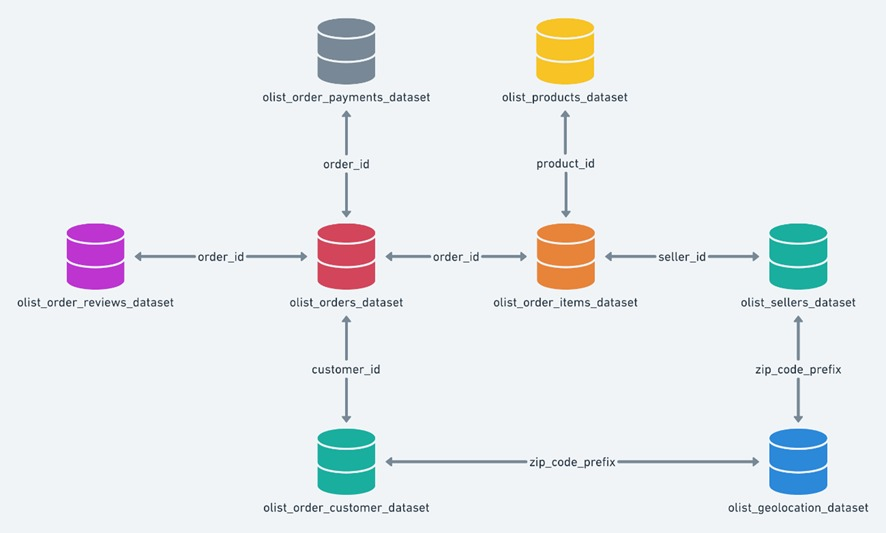

In [101]:
#Esquema Relacional Olist
from IPython.display import Image, display
display(Image('/content/esquema_chaves.jpeg', width=800))

A tabela central do modelo é `olist_orders_dataset`, que funciona como **hub de integração**: ela se conecta diretamente a clientes, pagamentos, itens de pedido e avaliações via `order_id` e `customer_id`. A partir dos itens de pedido, é possível acessar o catálogo de produtos e os vendedores. A tabela de geolocalização, por sua vez, enriquece clientes e vendedores com dados geográficos via `zip_code_prefix`.

#### **8.2 Construção das Bases Analíticas**

Para responder às perguntas de negócio definidas na Seção 2, não é possível trabalhar com cada tabela de forma isolada. Os KPIs exigem informações distribuídas por múltiplas tabelas. Exemplo: calcular a receita por categoria requer cruzar itens de pedido, produtos, pedidos e pagamentos simultaneamente.

Esse processo de **cruzamento entre tabelas** (joins relacionais) foi implementado via `pandas.merge()`, respeitando as chaves do modelo original. Além dos joins, aplicamos **agregações** — operações de `groupby` combinadas com funções de resumo (`sum`, `mean`, `count`, `nunique`) — para consolidar os dados no nível de granularidade adequado a cada KPI.

Vale registrar que duas colunas derivadas, criadas durante a etapa de limpeza, são centrais para a análise:

- **`product_category_clean`**: versão padronizada da categoria do produto, com agrupamento de subcategorias redundantes (ex.: todas as variações de `fashion_*` consolidadas em `vestuario`, múltiplas categorias de construção em `construcao`). Reduzimos de 73 para 41 categorias únicas.
- **`customer_city_clean`**: nome de cidade com capitalização padronizada via `.title()`, usada em visualizações.

A tabela abaixo resume as integrações realizadas para cada dimensão de análise:

| Dimensão | Tabelas Integradas | Chave de Junção | Nível de Agregação |
|---|---|---|---|
| **Receita** | `orders` + `payments` + `order_items` + `products` | `order_id`, `product_id` | Mensal / Por categoria |
| **Logística** | `orders` + `customers` | `order_id`, `customer_id` | Mensal / Por estado |
| **Satisfação** | `order_reviews` + `orders` | `order_id` | Mensal / Por faixa de atraso |

Em todos os casos, o escopo de análise foi restrito a pedidos com `order_status == 'delivered'`, garantindo que métricas de receita, tempo de entrega e avaliação reflitam apenas transações efetivamente concluídas — sem contaminação de pedidos cancelados, em processamento ou não entregues.

#### **8.3 Decisões Metodológicas**

Algumas escolhas merecem registro explícito para garantir rastreabilidade da análise:

**Fonte de receita:** utilizamos `payment_value` da tabela de pagamentos como proxy de receita, pois representa o valor efetivamente pago pelo cliente incluindo frete e combinações de métodos de pagamento. Para análise por categoria, usamos `price` dos itens, que isola o valor do produto sem frete.

**Referência temporal:** adotamos `order_purchase_timestamp` como âncora de data em todas as séries temporais, por ser a data de origem do pedido e estar disponível sem valores nulos.

**Base de avaliações:** utilizamos `df_avaliacoes_limpo` — versão após remoção das 814 duplicatas identificadas na etapa de limpeza (Seção 6.6) — para evitar distorção nas métricas de satisfação.

**Atraso:** definido como `order_delivered_customer_date > order_estimated_delivery_date`, calculado apenas sobre pedidos com data de entrega real disponível.

In [102]:
# Verificação: comparar datas de compra vs datas de avaliação em dez/2016
pedidos_dez2016 = df_pedidos[
    df_pedidos['order_purchase_timestamp'].dt.to_period('M') == '2016-12'
][['order_id', 'order_purchase_timestamp', 'order_delivered_customer_date']]

aval_dez2016 = df_avaliacoes_limpo[
    df_avaliacoes_limpo['review_creation_date'].dt.to_period('M') == '2016-12'
][['order_id', 'review_creation_date']]

print(f"Pedidos COMPRADOS em dez/2016: {len(pedidos_dez2016)}")
print(f"Avaliações CRIADAS em dez/2016: {len(aval_dez2016)}")

# De que mês são os pedidos que foram avaliados em dez/2016?
pedidos_das_avals = (
    aval_dez2016
    .merge(df_pedidos[['order_id', 'order_purchase_timestamp']], on='order_id', how='left')
)
pedidos_das_avals['mes_compra'] = pedidos_das_avals['order_purchase_timestamp'].dt.to_period('M')
print("\nMês de compra dos pedidos avaliados em dez/2016:")
print(pedidos_das_avals['mes_compra'].value_counts().sort_index())

Pedidos COMPRADOS em dez/2016: 1
Avaliações CRIADAS em dez/2016: 45

Mês de compra dos pedidos avaliados em dez/2016:
mes_compra
2016-10    44
2016-12     1
Freq: M, Name: count, dtype: int64


#### **8.4 Análise da Receita**


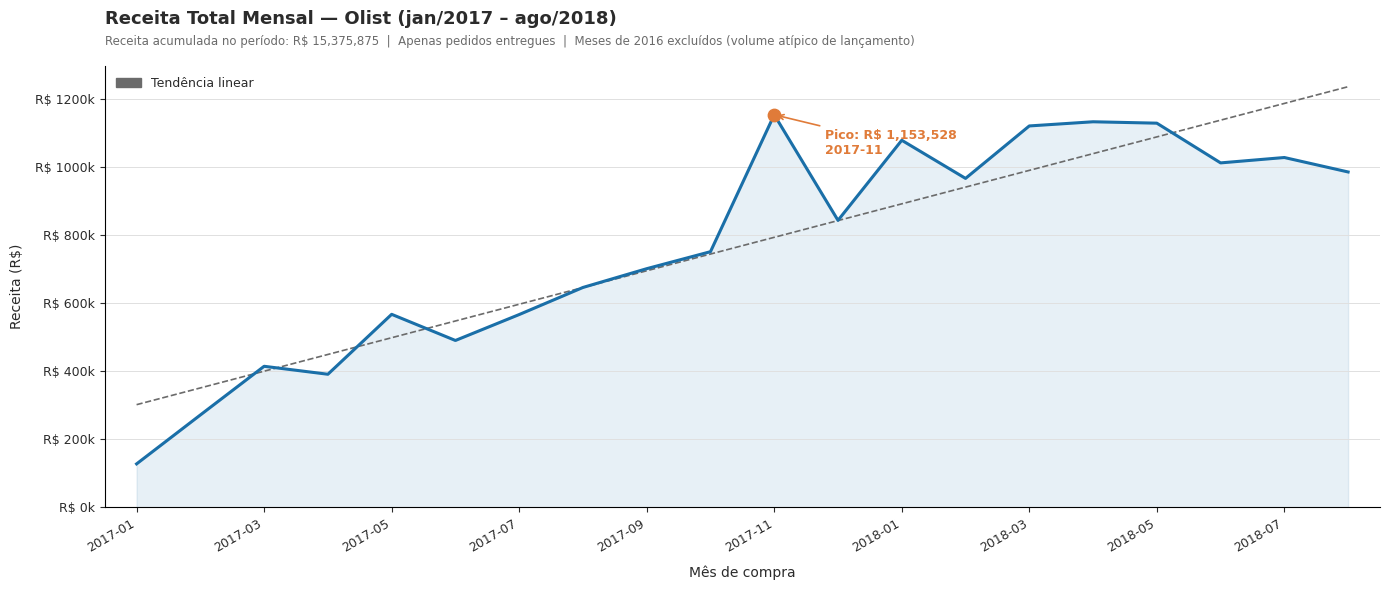

In [103]:
# ── Preparo dos dados ────────────────────────────────────────────────────────
# Corta meses de 2016 (período de lançamento com volume atípico)
df_plot = (
    df_kpi1_mensal
    .copy()
    .loc[df_kpi1_mensal['ano_mes'].astype(str) >= '2017-01']
    .reset_index(drop=True)
)
df_plot['ano_mes_str'] = df_plot['ano_mes'].astype(str)

x      = np.arange(len(df_plot))
y      = df_plot['receita_total'].values
labels = df_plot['ano_mes_str'].values

# ── Identifica pico ──────────────────────────────────────────────────────────
idx_pico = y.argmax()

# ── Paleta ───────────────────────────────────────────────────────────────────
CINZA_ESCURO  = '#2b2b2b'
CINZA_MEDIO   = '#6b6b6b'
CINZA_CLARO   = '#e0e0e0'
AZUL_DESTAQUE = '#1a6fa8'
LARANJA       = '#e07b39'

# ── rcParams ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : False,
    'text.color'       : CINZA_ESCURO,
    'axes.labelcolor'  : CINZA_ESCURO,
    'xtick.color'      : CINZA_ESCURO,
    'ytick.color'      : CINZA_ESCURO,
})

# ── Canvas ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Grid apenas horizontal
ax.yaxis.grid(True, color=CINZA_CLARO, linewidth=0.7, zorder=0)
ax.xaxis.grid(False)

# ── Área preenchida + linha principal ────────────────────────────────────────
ax.fill_between(x, y, alpha=0.10, color=AZUL_DESTAQUE, zorder=1)
ax.plot(x, y, color=AZUL_DESTAQUE, linewidth=2.2, zorder=3)

# ── Ponto de pico destacado ──────────────────────────────────────────────────
ax.scatter(x[idx_pico], y[idx_pico], color=LARANJA, s=80, zorder=5)
ax.annotate(
    f"Pico: R$ {y[idx_pico]:,.0f}\n{labels[idx_pico]}",
    xy=(x[idx_pico], y[idx_pico]),
    xytext=(x[idx_pico] + 0.8, y[idx_pico] * 0.90),
    fontsize=9,
    color=LARANJA,
    fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=LARANJA, lw=1.2),
)

# ── Linha de tendência ────────────────────────────────────────────────────────
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
ax.plot(x, p(x), linestyle='--', linewidth=1.2, color=CINZA_MEDIO, zorder=2)

# ── Eixo X ────────────────────────────────────────────────────────────────────
step = 2
ax.set_xticks(x[::step])
ax.set_xticklabels(labels[::step], rotation=30, ha='right', fontsize=9)
ax.set_xlim(-0.5, len(x) - 0.5)

# ── Eixo Y ────────────────────────────────────────────────────────────────────
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda val, _: f'R$ {val/1_000:.0f}k')
)
ax.tick_params(axis='y', labelsize=9)
ax.set_ylim(0)

# ── Título ────────────────────────────────────────────────────────────────────
ax.set_title(
    'Receita Total Mensal — Olist (jan/2017 – ago/2018)',
    fontsize=13, fontweight='bold', loc='left', pad=30, color=CINZA_ESCURO
)

# ── Subtítulo ─────────────────────────────────────────────────────────────────
ax.text(
    0, 1.04,
    f'Receita acumulada no período: R$ {df_plot["receita_total"].sum():,.0f}'
    f'  |  Apenas pedidos entregues  |  Meses de 2016 excluídos (volume atípico de lançamento)',
    transform=ax.transAxes,
    fontsize=8.5,
    color=CINZA_MEDIO,
    va='bottom'
)

# ── Rótulos dos eixos ─────────────────────────────────────────────────────────
ax.set_xlabel('Mês de compra', fontsize=10, labelpad=8)
ax.set_ylabel('Receita (R$)', fontsize=10, labelpad=8)

# ── Legenda ───────────────────────────────────────────────────────────────────
linha_tend = mpatches.Patch(color=CINZA_MEDIO, label='Tendência linear')
ax.legend(handles=[linha_tend], fontsize=9, frameon=False, loc='upper left')

plt.tight_layout()
plt.savefig('kpi1_receita_total.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

##### Análise de Escalabilidade e Consolidação de Receita

Este gráfico apresenta a evolução da receita mensal entre Janeiro de 2017 e Agosto de 2018.
O objetivo é demonstrar a **capacidade de escala** da operação e a estabilização em um novo patamar de faturamento.

### Destaques da Análise:
* **Crescimento Exponencial:** A receita expandiu **7.7x** no período de 19 meses.
* **CMGR:** A Taxa de Crescimento Mensal Composta foi de **11.4%**, indicando uma performance sólida e consistente.
* **Consolidação do Patamar:** Destacamos o período entre **Março/18 e Julho/18** como a consolidação acima de R$ 1M.
* **Observação sobre Agosto/18:** Embora o faturamento nominal de Agosto (R$ 985k) tenha ficado ligeiramente abaixo da linha de 1M, a **Média Móvel Trimestral** permanece acima do patamar, sugerindo que a capacidade operacional instalada continua estável, tratando a variação como ruído estatístico sazonal.

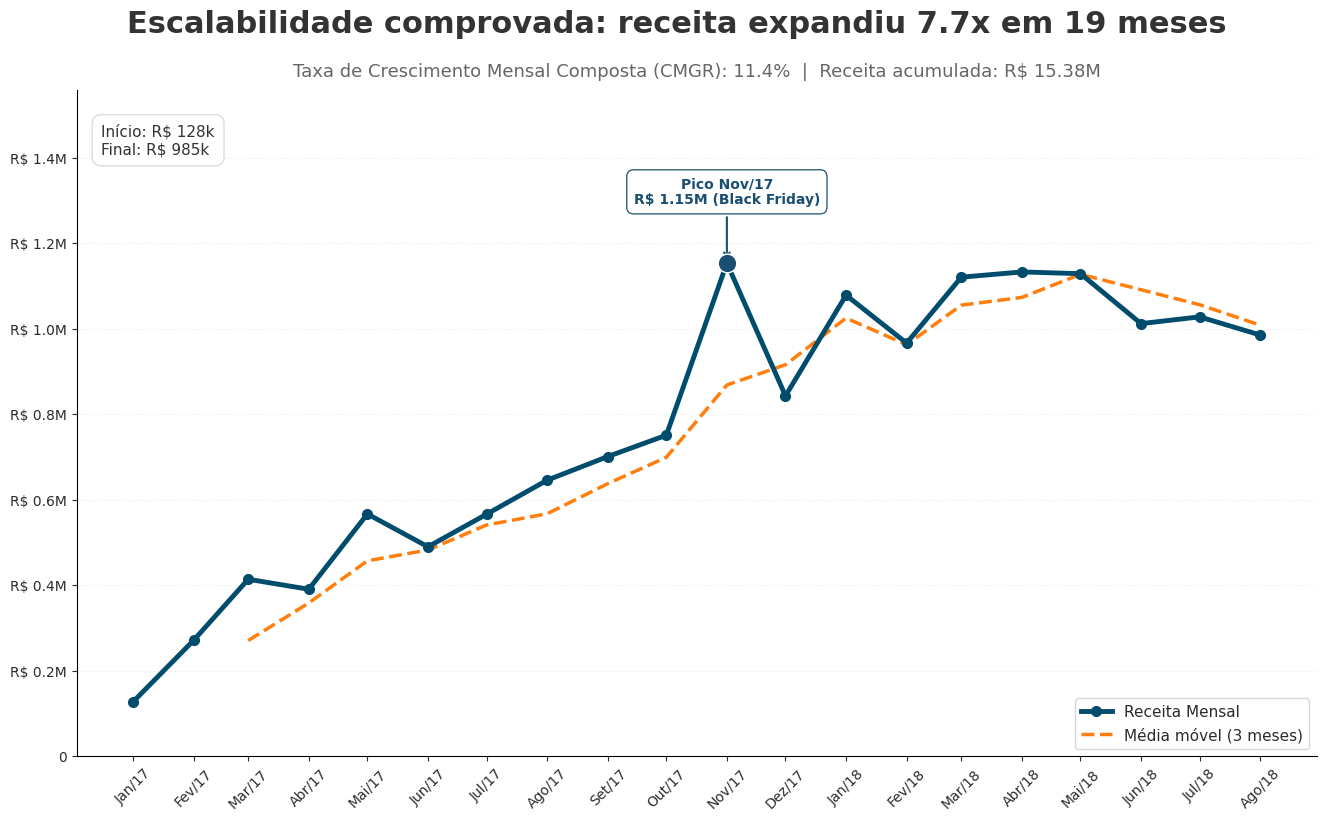

In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

# --- Preparo dos dados ---
df_plot = (
    df_kpi1_mensal
    .copy()
    .loc[df_kpi1_mensal['ano_mes'].astype(str) >= '2017-01']
    .reset_index(drop=True)
)
df_plot['data'] = df_plot['ano_mes'].dt.to_timestamp()
df_plot['mm3']  = df_plot['receita_total'].rolling(3).mean()

# --- Métricas ---
val_inicial    = df_plot['receita_total'].iloc[0]
val_final      = df_plot['receita_total'].iloc[-1]
multiplo       = val_final / val_inicial
n_meses        = len(df_plot) - 1
cmgr           = (multiplo) ** (1 / n_meses) - 1
receita_total  = df_plot['receita_total'].sum()

# Pico
idx_pico  = df_plot['receita_total'].idxmax()
data_pico = df_plot.loc[idx_pico, 'data']
val_pico  = df_plot.loc[idx_pico, 'receita_total']

# --- Visualização ---
AZUL_ESCURO, LARANJA, CINZA_TEXTO = '#004c6d', '#ff7f0e', '#333333'
CINZA_SUB, COR_PICO = '#666666', '#1b4f72'

fig, ax = plt.subplots(figsize=(16, 9), dpi=100)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Estética do Canvas
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
ax.yaxis.grid(True, linestyle=':', alpha=0.4, color='#cccccc')

# --- CAIXA DE RESUMO (Início/Final) ---
info_box = f"Início: R$ {val_inicial/1_000:.0f}k\nFinal: R$ {val_final/1_000:.0f}k"
ax.text(
    0.02, 0.95, info_box, transform=ax.transAxes, fontsize=11,
    bbox=dict(facecolor='white', edgecolor='#dddddd', boxstyle='round,pad=0.6'),
    color=CINZA_TEXTO, va='top', zorder=10
)

# Plotagem das Linhas
ax.plot(df_plot['data'], df_plot['receita_total'], color=AZUL_ESCURO, lw=3.5,
        marker='o', markersize=7, label='Receita Mensal', zorder=4)

ax.plot(df_plot['data'], df_plot['mm3'], color=LARANJA, ls='--', lw=2.5,
        label='Média móvel (3 meses)', zorder=3)

# Anotação de Pico
ax.scatter(data_pico, val_pico, color=COR_PICO, s=180, zorder=5, edgecolor='white')
ax.annotate(f'Pico Nov/17\nR$ {val_pico/1e6:.2f}M (Black Friday)', xy=(data_pico, val_pico),
            xytext=(data_pico, val_pico * 1.12), arrowprops=dict(arrowstyle='->', color=COR_PICO, lw=1.5),
            ha='center', fontweight='bold', color=COR_PICO,
            bbox=dict(boxstyle='round,pad=0.5', fc='white', ec=COR_PICO, alpha=0.9))

# Eixos
meses_pt = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{meses_pt[mdates.num2date(x).month-1]}/{str(mdates.num2date(x).year)[2:]}"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'R$ {x/1e6:.1f}M' if x > 0 else '0'))

plt.xticks(rotation=45)
ax.set_ylim(0, val_pico * 1.35)

# --- AJUSTE DOS TÍTULOS ---
plt.suptitle(f'Escalabilidade comprovada: receita expandiu {multiplo:.1f}x em {n_meses} meses',
             fontsize=22, fontweight='bold', y=0.94, color=CINZA_TEXTO)

ax.set_title(f'Taxa de Crescimento Mensal Composta (CMGR): {cmgr*100:.1f}%  |  Receita acumulada: R$ {receita_total/1e6:.2f}M',
             fontsize=13, color=CINZA_SUB, pad=10)

ax.legend(loc='lower right', frameon=True, facecolor='white', fontsize=11)

plt.subplots_adjust(top=0.85)
plt.show()

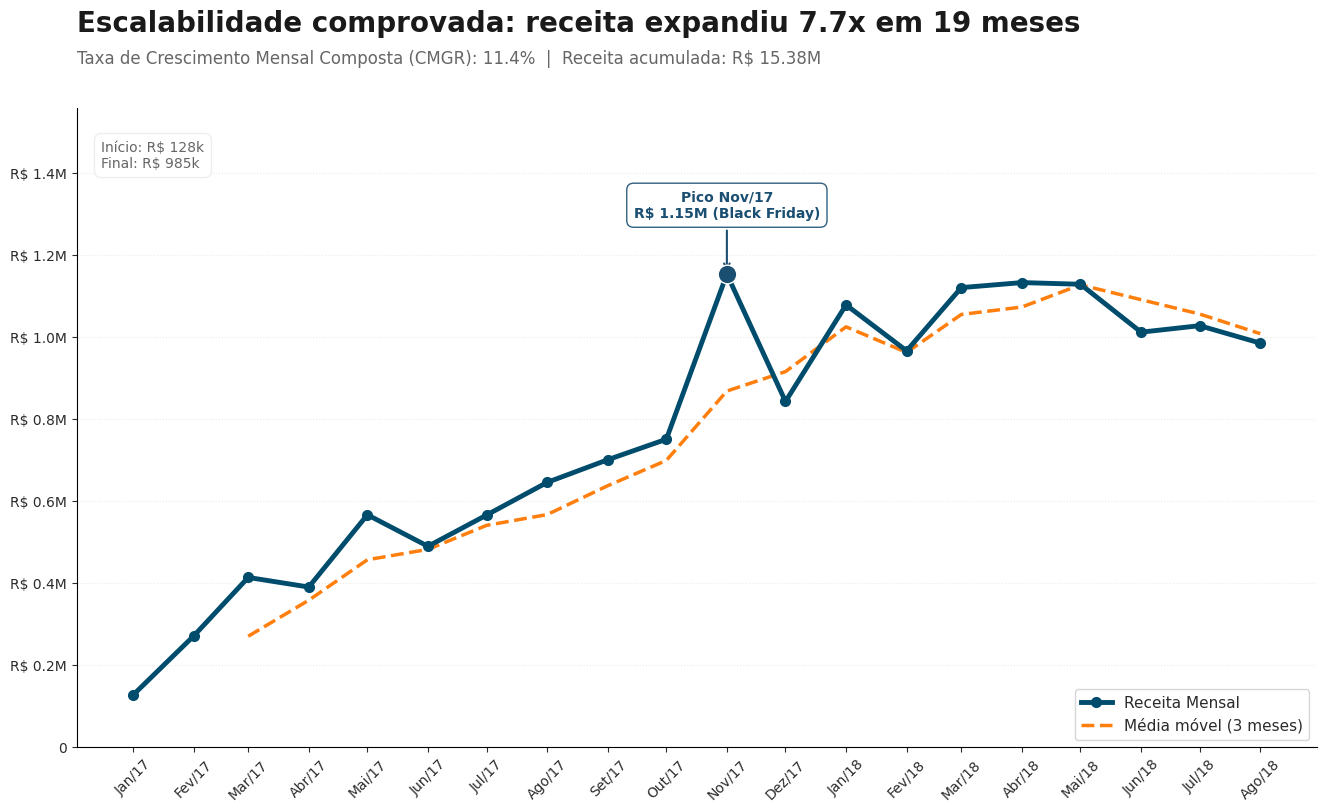

In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

# --- Preparo dos dados ---
df_plot = (
    df_kpi1_mensal
    .copy()
    .loc[df_kpi1_mensal['ano_mes'].astype(str) >= '2017-01']
    .reset_index(drop=True)
)
df_plot['data'] = df_plot['ano_mes'].dt.to_timestamp()
df_plot['mm3']  = df_plot['receita_total'].rolling(3).mean()

# --- Métricas ---
val_inicial    = df_plot['receita_total'].iloc[0]
val_final      = df_plot['receita_total'].iloc[-1]
multiplo       = val_final / val_inicial
n_meses        = len(df_plot) - 1
cmgr           = (multiplo) ** (1 / n_meses) - 1
receita_total  = df_plot['receita_total'].sum()

# Pico
idx_pico  = df_plot['receita_total'].idxmax()
data_pico = df_plot.loc[idx_pico, 'data']
val_pico  = df_plot.loc[idx_pico, 'receita_total']

# --- Visualização ---
AZUL_ESCURO, LARANJA, CINZA_TEXTO = '#004c6d', '#ff7f0e', '#1A1A1A'
CINZA_SUB, COR_PICO = '#666666', '#1b4f72'

fig, ax = plt.subplots(figsize=(16, 9), dpi=100)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Estética do Canvas
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
ax.yaxis.grid(True, linestyle=':', alpha=0.4, color='#cccccc')

# --- CAIXA DE RESUMO (Início/Final) ---
info_box = f"Início: R$ {val_inicial/1_000:.0f}k\nFinal: R$ {val_final/1_000:.0f}k"
ax.text(
    0.02, 0.95, info_box, transform=ax.transAxes, fontsize=10,
    bbox=dict(facecolor='white', edgecolor='#eeeeee', boxstyle='round,pad=0.5'),
    color=CINZA_SUB, va='top', zorder=10
)

# Plotagem das Linhas
ax.plot(df_plot['data'], df_plot['receita_total'], color=AZUL_ESCURO, lw=3.5,
        marker='o', markersize=7, label='Receita Mensal', zorder=4)

ax.plot(df_plot['data'], df_plot['mm3'], color=LARANJA, ls='--', lw=2.5,
        label='Média móvel (3 meses)', zorder=3)

# Anotação de Pico
ax.scatter(data_pico, val_pico, color=COR_PICO, s=180, zorder=5, edgecolor='white')
ax.annotate(f'Pico Nov/17\nR$ {val_pico/1e6:.2f}M (Black Friday)', xy=(data_pico, val_pico),
            xytext=(data_pico, val_pico * 1.12), arrowprops=dict(arrowstyle='->', color=COR_PICO, lw=1.5),
            ha='center', fontweight='bold', color=COR_PICO,
            bbox=dict(boxstyle='round,pad=0.5', fc='white', ec=COR_PICO, alpha=0.9))

# Eixos
meses_pt = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{meses_pt[mdates.num2date(x).month-1]}/{str(mdates.num2date(x).year)[2:]}"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'R$ {x/1e6:.1f}M' if x > 0 else '0'))

plt.xticks(rotation=45)
ax.set_ylim(0, val_pico * 1.35)

# --- TÍTULOS JUSTIFICADOS À ESQUERDA (Estilo Elegante) ---
# Usamos ax.text para controle total da posição horizontal (x=0)
ax.text(0, 1.12, f'Escalabilidade comprovada: receita expandiu {multiplo:.1f}x em {n_meses} meses',
        transform=ax.transAxes, fontsize=20, fontweight='bold', color=CINZA_TEXTO, ha='left')

ax.text(0, 1.07, f'Taxa de Crescimento Mensal Composta (CMGR): {cmgr*100:.1f}%  |  Receita acumulada: R$ {receita_total/1e6:.2f}M',
        transform=ax.transAxes, fontsize=12, color=CINZA_SUB, ha='left')

ax.legend(loc='lower right', frameon=True, facecolor='white', fontsize=11)

# Ajuste da margem superior para acomodar os novos títulos
plt.subplots_adjust(top=0.82)

plt.show()

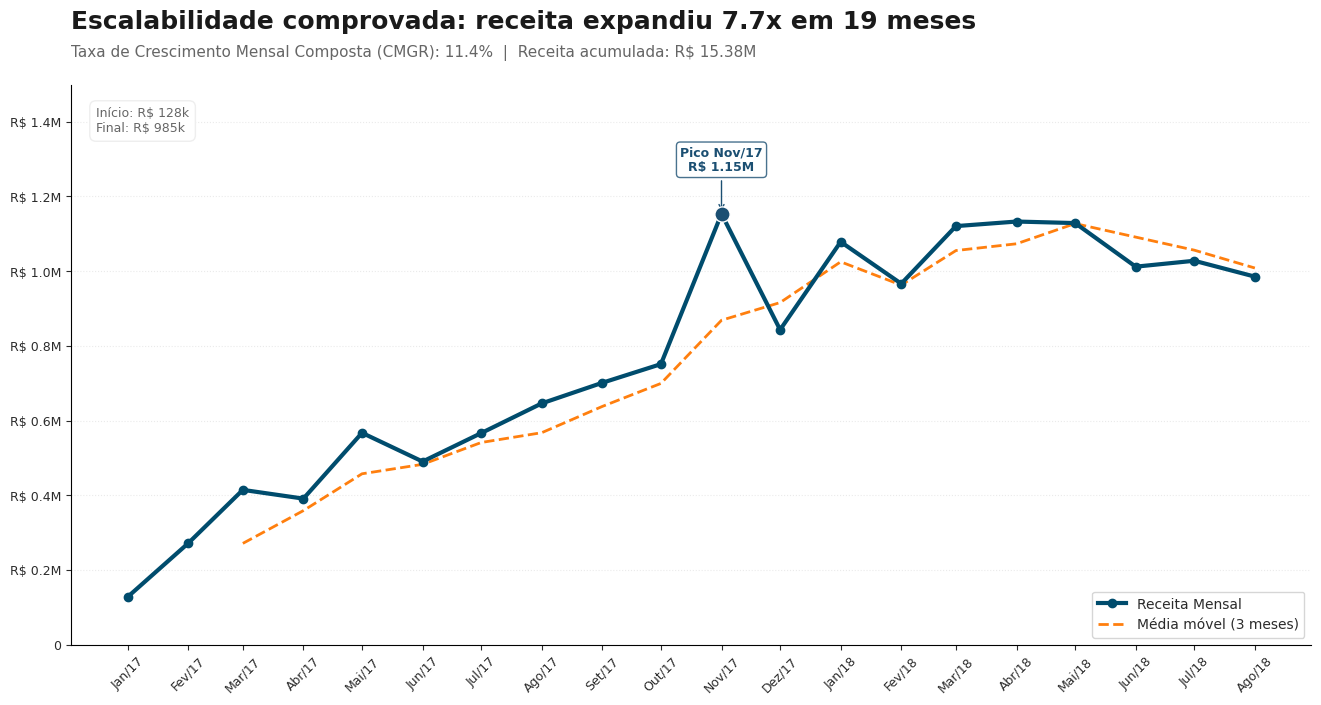

In [106]:
# ... (mantenha a parte inicial do preparo dos dados e métricas igual)

# --- Visualização Refinada ---
AZUL_ESCURO, LARANJA, CINZA_TEXTO = '#004c6d', '#ff7f0e', '#1A1A1A'
CINZA_SUB, COR_PICO = '#666666', '#1b4f72'

fig, ax = plt.subplots(figsize=(16, 8), dpi=100) # Reduzi levemente a altura para compactar
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
ax.yaxis.grid(True, linestyle=':', alpha=0.4, color='#cccccc')

# --- CAIXA DE RESUMO (Início/Final) - Fonte reduzida para discrição ---
info_box = f"Início: R$ {val_inicial/1_000:.0f}k\nFinal: R$ {val_final/1_000:.0f}k"
ax.text(
    0.02, 0.96, info_box, transform=ax.transAxes, fontsize=9,
    bbox=dict(facecolor='white', edgecolor='#eeeeee', boxstyle='round,pad=0.5'),
    color=CINZA_SUB, va='top', zorder=10
)

# Plotagem
ax.plot(df_plot['data'], df_plot['receita_total'], color=AZUL_ESCURO, lw=3,
        marker='o', markersize=6, label='Receita Mensal', zorder=4)

ax.plot(df_plot['data'], df_plot['mm3'], color=LARANJA, ls='--', lw=2,
        label='Média móvel (3 meses)', zorder=3)

# Anotação de Pico - Ajuste de escala
ax.scatter(data_pico, val_pico, color=COR_PICO, s=120, zorder=5, edgecolor='white')
ax.annotate(f'Pico Nov/17\nR$ {val_pico/1e6:.2f}M', xy=(data_pico, val_pico),
            xytext=(data_pico, val_pico * 1.1), arrowprops=dict(arrowstyle='->', color=COR_PICO),
            ha='center', fontweight='bold', color=COR_PICO, fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=COR_PICO, alpha=0.8))

# Eixos
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{meses_pt[mdates.num2date(x).month-1]}/{str(mdates.num2date(x).year)[2:]}"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'R$ {x/1e6:.1f}M' if x > 0 else '0'))
plt.xticks(rotation=45, fontsize=9)
plt.yticks(fontsize=9)
ax.set_ylim(0, val_pico * 1.3)

# --- TÍTULOS JUSTIFICADOS COM FONTES EQUILIBRADAS ---
ax.text(0, 1.10, f'Escalabilidade comprovada: receita expandiu {multiplo:.1f}x em {n_meses} meses',
        transform=ax.transAxes, fontsize=18, fontweight='bold', color=CINZA_TEXTO, ha='left')

ax.text(0, 1.05, f'Taxa de Crescimento Mensal Composta (CMGR): {cmgr*100:.1f}%  |  Receita acumulada: R$ {receita_total/1e6:.2f}M',
        transform=ax.transAxes, fontsize=11, color=CINZA_SUB, ha='left')

ax.legend(loc='lower right', frameon=True, facecolor='white', fontsize=10)
plt.subplots_adjust(top=0.85, bottom=0.15)

plt.show()

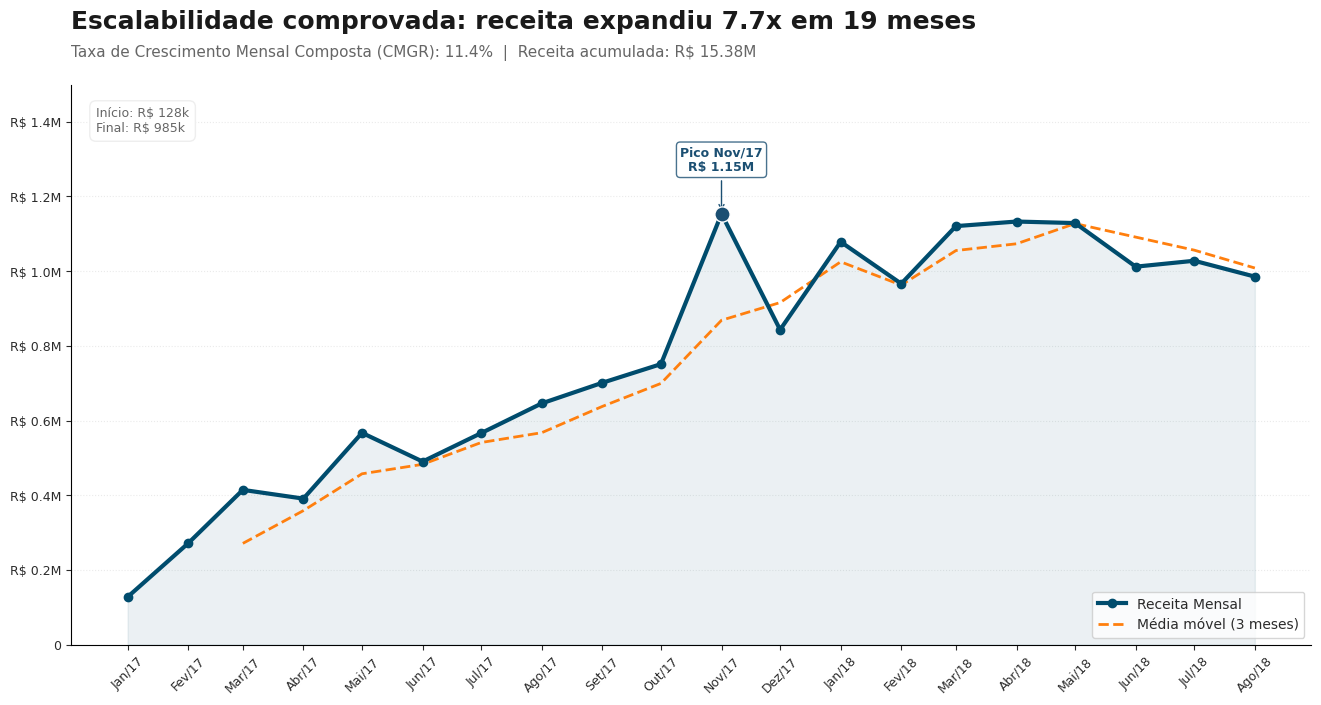

In [107]:
# ... (mantenha a parte inicial do preparo dos dados e métricas igual)

# --- Visualização com Preenchimento (Area Chart) ---
AZUL_ESCURO, LARANJA, CINZA_TEXTO = '#004c6d', '#ff7f0e', '#1A1A1A'
CINZA_SUB, COR_PICO = '#666666', '#1b4f72'

fig, ax = plt.subplots(figsize=(16, 8), dpi=100)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
ax.yaxis.grid(True, linestyle=':', alpha=0.4, color='#cccccc')

# --- NOVO: Preenchimento de Área (Efeito Elegante) ---
# Usamos uma cor azul bem clara com alpha baixo para não competir com as linhas
ax.fill_between(df_plot['data'], df_plot['receita_total'], color=AZUL_ESCURO, alpha=0.08, zorder=2)

# --- CAIXA DE RESUMO ---
info_box = f"Início: R$ {val_inicial/1_000:.0f}k\nFinal: R$ {val_final/1_000:.0f}k"
ax.text(0.02, 0.96, info_box, transform=ax.transAxes, fontsize=9,
        bbox=dict(facecolor='white', edgecolor='#eeeeee', boxstyle='round,pad=0.5'),
        color=CINZA_SUB, va='top', zorder=10)

# Linhas principais
ax.plot(df_plot['data'], df_plot['receita_total'], color=AZUL_ESCURO, lw=3,
        marker='o', markersize=6, label='Receita Mensal', zorder=4)

ax.plot(df_plot['data'], df_plot['mm3'], color=LARANJA, ls='--', lw=2,
        label='Média móvel (3 meses)', zorder=3)

# Anotação de Pico
ax.scatter(data_pico, val_pico, color=COR_PICO, s=120, zorder=5, edgecolor='white')
ax.annotate(f'Pico Nov/17\nR$ {val_pico/1e6:.2f}M', xy=(data_pico, val_pico),
            xytext=(data_pico, val_pico * 1.1), arrowprops=dict(arrowstyle='->', color=COR_PICO),
            ha='center', fontweight='bold', color=COR_PICO, fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=COR_PICO, alpha=0.8))

# Eixos e Títulos (Justificados à esquerda)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{meses_pt[mdates.num2date(x).month-1]}/{str(mdates.num2date(x).year)[2:]}"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'R$ {x/1e6:.1f}M' if x > 0 else '0'))
plt.xticks(rotation=45, fontsize=9)
plt.yticks(fontsize=9)
ax.set_ylim(0, val_pico * 1.3)

ax.text(0, 1.10, f'Escalabilidade comprovada: receita expandiu {multiplo:.1f}x em {n_meses} meses',
        transform=ax.transAxes, fontsize=18, fontweight='bold', color=CINZA_TEXTO, ha='left')

ax.text(0, 1.05, f'Taxa de Crescimento Mensal Composta (CMGR): {cmgr*100:.1f}%  |  Receita acumulada: R$ {receita_total/1e6:.2f}M',
        transform=ax.transAxes, fontsize=11, color=CINZA_SUB, ha='left')

ax.legend(loc='lower right', frameon=True, facecolor='white', fontsize=10)
plt.subplots_adjust(top=0.85, bottom=0.15)

plt.show()

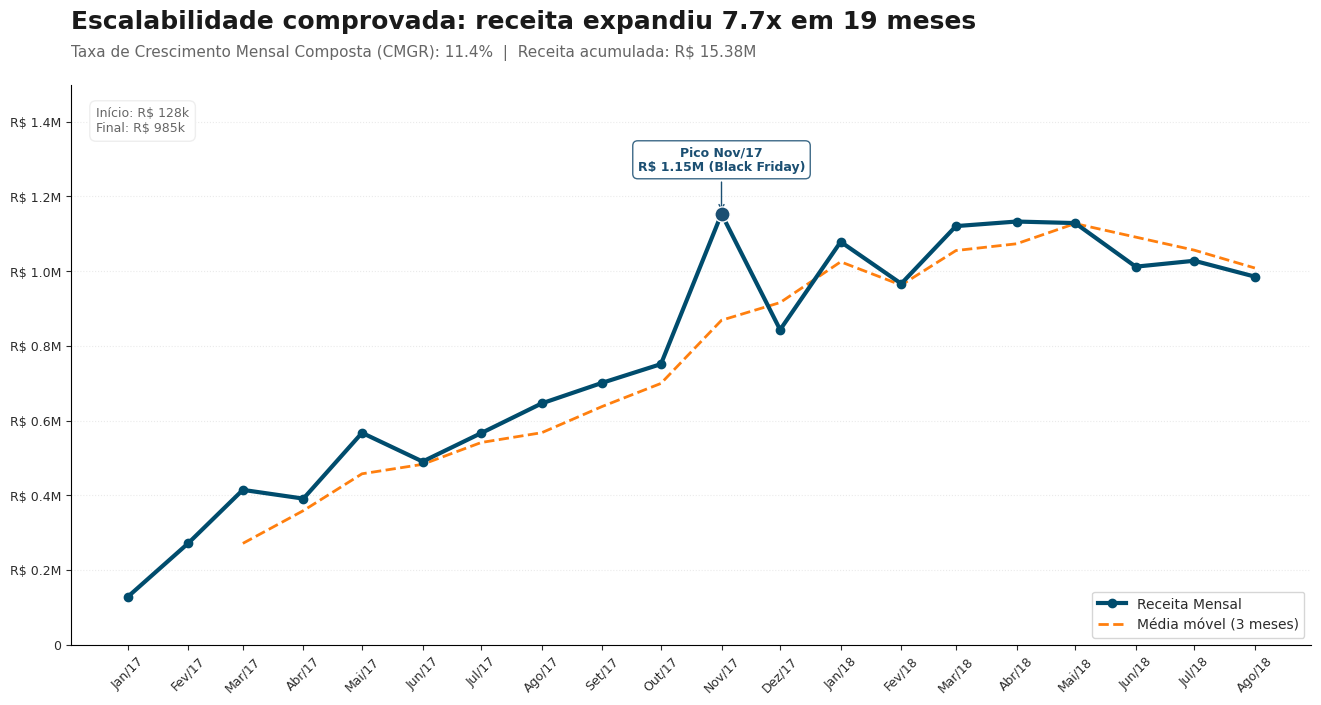

In [108]:
# ... (mantenha a parte inicial do preparo dos dados e métricas igual)

# --- Visualização Ultra-Clean (Sem preenchimento) ---
AZUL_ESCURO, LARANJA, CINZA_TEXTO = '#004c6d', '#ff7f0e', '#1A1A1A'
CINZA_SUB, COR_PICO = '#666666', '#1b4f72'

fig, ax = plt.subplots(figsize=(16, 8), dpi=100)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Remoção de bordas desnecessárias
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
ax.yaxis.grid(True, linestyle=':', alpha=0.4, color='#cccccc')

# --- CAIXA DE RESUMO (Início/Final) ---
info_box = f"Início: R$ {val_inicial/1_000:.0f}k\nFinal: R$ {val_final/1_000:.0f}k"
ax.text(0.02, 0.96, info_box, transform=ax.transAxes, fontsize=9,
        bbox=dict(facecolor='white', edgecolor='#eeeeee', boxstyle='round,pad=0.5'),
        color=CINZA_SUB, va='top', zorder=10)

# Plotagem das Linhas Principais
ax.plot(df_plot['data'], df_plot['receita_total'], color=AZUL_ESCURO, lw=3,
        marker='o', markersize=6, label='Receita Mensal', zorder=4)

ax.plot(df_plot['data'], df_plot['mm3'], color=LARANJA, ls='--', lw=2,
        label='Média móvel (3 meses)', zorder=3)

# --- ANOTAÇÃO DE PICO (Foco na Black Friday) ---
ax.scatter(data_pico, val_pico, color=COR_PICO, s=120, zorder=5, edgecolor='white')
ax.annotate(f'Pico Nov/17\nR$ {val_pico/1e6:.2f}M (Black Friday)', xy=(data_pico, val_pico),
            xytext=(data_pico, val_pico * 1.1), arrowprops=dict(arrowstyle='->', color=COR_PICO),
            ha='center', fontweight='bold', color=COR_PICO, fontsize=9,
            bbox=dict(boxstyle='round,pad=0.4', fc='white', ec=COR_PICO, alpha=0.85))

# Formatação de Eixos
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{meses_pt[mdates.num2date(x).month-1]}/{str(mdates.num2date(x).year)[2:]}"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'R$ {x/1e6:.1f}M' if x > 0 else '0'))

plt.xticks(rotation=45, fontsize=9)
plt.yticks(fontsize=9)
ax.set_ylim(0, val_pico * 1.3)

# --- TÍTULOS JUSTIFICADOS À ESQUERDA ---
ax.text(0, 1.10, f'Escalabilidade comprovada: receita expandiu {multiplo:.1f}x em {n_meses} meses',
        transform=ax.transAxes, fontsize=18, fontweight='bold', color=CINZA_TEXTO, ha='left')

ax.text(0, 1.05, f'Taxa de Crescimento Mensal Composta (CMGR): {cmgr*100:.1f}%  |  Receita acumulada: R$ {receita_total/1e6:.2f}M',
        transform=ax.transAxes, fontsize=11, color=CINZA_SUB, ha='left')

ax.legend(loc='lower right', frameon=True, facecolor='white', fontsize=10)
plt.subplots_adjust(top=0.85, bottom=0.15)

plt.show()

In [109]:
# ▶ Rode isso logo após gerar o gráfico 1, antes do código do KPI 2
data_inicio_ref = df_plot['data'].min()  # Jan/17
data_fim_ref    = df_plot['data'].max()  # Ago/18

In [110]:
import pandas as pd

def classificar_variavel(serie):
    # Remover nulos para análise de cardinalidade e tipos
    serie_clean = serie.dropna()
    if serie_clean.empty:
        return "Vazia/Nula"

    # 1. Datas e Períodos (Tipos nativos)
    if pd.api.types.is_datetime64_any_dtype(serie) or pd.api.types.is_period_dtype(serie):
        return "Temporal"

    # 2. Booleanos
    if pd.api.types.is_bool_dtype(serie):
        return "Categórica (Binária)"

    # 3. Numéricas
    if pd.api.types.is_numeric_dtype(serie):
        n_unicos = serie_clean.nunique()
        if n_unicos <= 10:
            return "Categórica (Discreta/Ordinal)"
        if pd.api.types.is_integer_dtype(serie):
            return "Quantitativa Discreta"
        return "Quantitativa Contínua"

    # 4. Strings e Objetos (Verificação de data implícita)
    if serie.dtype == "object" or pd.api.types.is_string_dtype(serie):
        # Tenta converter apenas se houver potencial de ser data
        sample = serie_clean.astype(str).head(100) # Amostra para performance
        try:
            convertido = pd.to_datetime(sample, errors='coerce')
            if convertido.notna().sum() / len(sample) > 0.8:
                return "Temporal (String)"
        except:
            pass

        return "Nominal/Texto"

    return "Desconhecido"

In [111]:
resumo = df_kpi2.apply(classificar_variavel)
print(resumo)

ano_mes                       Temporal
receita_total    Quantitativa Contínua
qtd_pedidos      Quantitativa Discreta
ticket_medio     Quantitativa Contínua
dtype: object


In [112]:
print(df_kpi1_mensal["ano_mes"].head())

0    2016-10
1    2016-12
2    2017-01
3    2017-02
4    2017-03
Name: ano_mes, dtype: period[M]


In [113]:
classificacao = df_kpi2.apply(classificar_variavel)
print(classificacao)

ano_mes                       Temporal
receita_total    Quantitativa Contínua
qtd_pedidos      Quantitativa Discreta
ticket_medio     Quantitativa Contínua
dtype: object


In [114]:
import pandas as pd
import numpy as np

# --- 1. SUA FUNÇÃO DE CLASSIFICAÇÃO (Melhorada) ---
def classificar_variavel(serie):
    """Classifica o tipo de variável de uma Series do Pandas."""
    # Remover nulos para análise de cardinalidade e tipos
    serie_clean = serie.dropna()

    # Check inicial para séries vazias ou que só possuem NaN
    if serie_clean.empty:
        return "Vazia/Nula"

    # Datas e Períodos (Tipos nativos do Pandas)
    if pd.api.types.is_datetime64_any_dtype(serie) or pd.api.types.is_period_dtype(serie):
        return "Temporal"

    # Booleanos explicitamente tratados
    if pd.api.types.is_bool_dtype(serie):
        return "Categórica Binária"

    # Numéricas
    if pd.api.types.is_numeric_dtype(serie):
        # Para decidir entre discreta (contagem) e contínua (medição)
        # O limite de 10 é uma heurística comum, você pode ajustar.
        if serie_clean.nunique() <= 10:
            return "Categórica (Discreta)"
        elif pd.api.types.is_integer_dtype(serie):
            return "Quantitativa Discreta"
        else:
            return "Quantitativa Contínua"

    # Strings e Objetos Genéricos
    if serie.dtype == "object" or pd.api.types.is_string_dtype(serie):
        # Tenta converter uma amostra para data (performance)
        # para identificar colunas de data que foram lidas como string.
        amostra = serie_clean.astype(str).head(100)
        try:
            convertido = pd.to_datetime(amostra, errors='coerce')
            # Se a grande maioria na amostra for data, assume que é temporal
            if convertido.notna().sum() / len(amostra) > 0.8:
                return "Temporal (String)"
        except:
            pass # Se der erro, não é data

        return "Nominal" # Padrão para texto não-temporal

    # Caso não se encaixe em nada acima
    return "Outro/Misto"

# --- 2. NOVA FUNÇÃO DE SUGESTÃO (Alinhada com as categorias acima) ---
def sugerir_grafico_para_tipo(classificacao):
    """Sugere tipos de gráficos com base na classificação da variável."""

    if classificacao == "Nominal":
        return "Gráfico de Barras (Contagem) ou Gráfico de Pizza (Se poucas categorias)"

    if classificacao == "Categórica (Discreta)":
        return "Gráfico de Barras (Contagem)"

    if classificacao == "Categórica Binária":
        return "Gráfico de Barras (Proporção) ou Gráfico de Pizza"

    if classificacao == "Quantitativa Discreta":
        return "Gráfico de Barras (Contagem de valores) ou Histograma"

    if classificacao == "Quantitativa Contínua":
        return "Histograma ou Boxplot"

    if classificacao in ["Temporal", "Temporal (String)"]:
        return "Gráfico de Linha (Série Temporal)"

    if classificacao == "Vazia/Nula":
        return "(Nenhum gráfico recomendado)"

    return "Análise manual necessária"

# --- 3. EXEMPLO DE COMO APLICAR O PIPELINE ---

# Criando um DataFrame de exemplo
data = {
    'cidade': ['SP', 'RJ', 'SP', 'MG', 'BA'],
    'temperatura': [25.5, 30.2, 22.8, np.nan, 28.1],
    'numero_quartos': [1, 2, 2, 3, 1],
    'data_venda': ['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04', '2023-01-05'],
    'e_novo': [True, False, True, False, False],
    'comentarios': [np.nan, np.nan, np.nan, np.nan, np.nan] # Coluna vazia
}
df = pd.DataFrame(data)
# Converter a coluna de data para datetime nativo
df['data_venda_nativa'] = pd.to_datetime(df['data_venda'])

print("--- DataFrame de Exemplo ---")
print(df.info())
print("\n")

# Passo 1: Classificar todas as variáveis
classificacoes_variaveis = df.apply(classificar_variavel)

print("--- Passo 1: Classificação das Variáveis ---")
print(classificacoes_variaveis)
print("\n")

# Passo 2: Gerar sugestões de gráficos para cada variável
# Usamos um dictionary comprehension, similar ao exemplo do professor
sugestoes_graficos = {coluna: sugerir_grafico_para_tipo(tipo)
                      for coluna, tipo in classificacoes_variaveis.items()}

print("--- Passo 2: Sugestões de Gráficos ---")
for col, sug in sugestoes_graficos.items():
    tipo_orig = classificacoes_variaveis[col]
    print(f"Coluna: '{col}' (Tipo: {tipo_orig}) -> Sugestão: {sug}")

--- DataFrame de Exemplo ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   cidade             5 non-null      object        
 1   temperatura        4 non-null      float64       
 2   numero_quartos     5 non-null      int64         
 3   data_venda         5 non-null      object        
 4   e_novo             5 non-null      bool          
 5   comentarios        0 non-null      float64       
 6   data_venda_nativa  5 non-null      datetime64[ns]
dtypes: bool(1), datetime64[ns](1), float64(2), int64(1), object(2)
memory usage: 377.0+ bytes
None


--- Passo 1: Classificação das Variáveis ---
cidade                             Nominal
temperatura          Categórica (Discreta)
numero_quartos       Categórica (Discreta)
data_venda               Temporal (String)
e_novo                  Categórica Binária
comentarios   

In [115]:
classificacao = df_kpi2.apply(classificar_variavel)
print(classificacao)

ano_mes                       Temporal
receita_total    Quantitativa Contínua
qtd_pedidos      Quantitativa Discreta
ticket_medio     Quantitativa Contínua
dtype: object


In [116]:
sugestoes = classificacao.apply(sugerir_grafico_para_tipo)
print(sugestoes)

ano_mes                          Gráfico de Linha (Série Temporal)
receita_total                                Histograma ou Boxplot
qtd_pedidos      Gráfico de Barras (Contagem de valores) ou His...
ticket_medio                                 Histograma ou Boxplot
dtype: object


In [117]:
def sugerir_relacao(col_nome_x, col_nome_y, df):
    # Primeiro classificamos cada uma usando sua função original
    tipo_x = classificar_variavel(df[col_nome_x])
    tipo_y = classificar_variavel(df[col_nome_y])

    # Lógica de cruzamento
    if "Temporal" in tipo_x and "Quantitativa" in tipo_y:
        return f"Gráfico de Linha: Evolução de {col_nome_y} ao longo de {col_nome_x}"

    if "Nominal" in tipo_x and "Quantitativa" in tipo_y:
        return f"Gráfico de Barras: Comparação de {col_nome_y} por {col_nome_x}"

    if "Quantitativa" in tipo_x and "Quantitativa" in tipo_y:
        return f"Gráfico de Dispersão: Correlação entre {col_nome_x} e {col_nome_y}"

    return "Cruzamento complexo: Sugerimos análise de tabela dinâmica"

# Exemplo de uso:
print(sugerir_relacao('ano_mes', 'ticket_medio', df_kpi2))

Gráfico de Linha: Evolução de ticket_medio ao longo de ano_mes


In [118]:
relacao = sugerir_relacao('ano_mes', 'ticket_medio', df_kpi2)
print(relacao)

Gráfico de Linha: Evolução de ticket_medio ao longo de ano_mes


Para complementar a análise exploratória, foram desenvolvidas duas funções auxiliares. A primeira automatiza a identificação da natureza estatística das variáveis, enquanto a segunda sugere a representação gráfica mais adequada para cada tipo de dado identificado.

In [119]:
def classificar_variavel(serie):
    """
    Classifica a natureza estatística de uma Series (coluna) do Pandas.

    Parâmetros:
    serie (pd.Series): A coluna do DataFrame a ser classificada.

    Retornos:
    str: Uma string contendo a classificação (ex: 'Temporal', 'Nominal', 'Quantitativa Contínua').
    """
    # Remoção de nulos para análise de tipos e cardinalidade
    serie_clean = serie.dropna()
    if serie_clean.empty:
        return "Vazia/Nula"

    # Identificação de tipos temporais nativos
    if pd.api.types.is_datetime64_any_dtype(serie) or pd.api.types.is_period_dtype(serie):
        return "Temporal"

    # Identificação de booleanos
    if pd.api.types.is_bool_dtype(serie):
        return "Categórica Binária"

    # Identificação de variáveis numéricas
    if pd.api.types.is_numeric_dtype(serie):
        # Heurística: menos de 10 valores únicos indica natureza categórica/ordinal
        if serie_clean.nunique() <= 10:
            return "Categórica (Discreta)"
        # Diferenciação entre discreta (inteiros) e contínua (floats)
        elif pd.api.types.is_integer_dtype(serie):
            return "Quantitativa Discreta"
        else:
            return "Quantitativa Contínua"

    # Identificação de strings/object
    if serie.dtype == "object" or pd.api.types.is_string_dtype(serie):
        # Teste de conversão para identificar datas armazenadas como string
        amostra = serie_clean.astype(str).head(100)
        try:
            if pd.to_datetime(amostra, errors='coerce').notna().sum() / len(amostra) > 0.8:
                return "Temporal (String)"
        except:
            pass
        return "Nominal"

    return "Outro/Misto"


def sugerir_grafico(classificacao):
    """
    Sugere o tipo de gráfico ideal com base na classificação estatística da variável.

    Parâmetros:
    classificacao (str): O tipo da variável (retorno da função classificar_variavel).

    Retornos:
    str: Uma string com a recomendação do gráfico (ex: 'Histograma', 'Gráfico de Linhas').
    """
    sugestoes = {
        "Nominal": "Gráfico de Barras (Contagem)",
        "Categórica (Discreta)": "Gráfico de Barras",
        "Quantitativa Discreta": "Histograma ou Gráfico de Barras",
        "Quantitativa Contínua": "Histograma ou Boxplot",
        "Temporal": "Gráfico de Linha (Série Temporal)",
        "Temporal (String)": "Gráfico de Linha (após conversão para Datetime)",
        "Categórica Binária": "Gráfico de Barras ou Pizza",
        "Vazia/Nula": "Nenhum (Coluna sem dados)"
    }

    return sugestoes.get(classificacao, "Análise manual recomendada")

6.4 Função de Sugestão Bivariada (Cruzamento)
Para análises que envolvem a relação entre duas variáveis, esta função identifica a combinação dos tipos de dados e sugere a abordagem visual mais adequada para evidenciar correlações, tendências ou diferenças entre grupos.

In [120]:
def sugerir_relacao(df, col_x, col_y):
    """
    Analisa a relação entre duas colunas e sugere o gráfico bivariado ideal.

    Parâmetros:
    df (pd.DataFrame): O DataFrame contendo os dados.
    col_x (str): O nome da coluna que ficará no eixo X.
    col_y (str): O nome da coluna que ficará no eixo Y.

    Retornos:
    str: Uma string com a recomendação de cruzamento (ex: 'Gráfico de Dispersão', 'Boxplot').
    """
    # Utiliza a função de classificação univariada para entender a natureza de cada coluna
    tipo_x = classificar_variavel(df[col_x])
    tipo_y = classificar_variavel(df[col_y])

    # Lógica de Cruzamento:

    # 1. Evolução Temporal (Tempo vs Quantidade)
    if "Temporal" in tipo_x and "Quantitativa" in tipo_y:
        return f"Gráfico de Linhas: Para observar a evolução de '{col_y}' ao longo de '{col_x}'."

    # 2. Correlação entre duas métricas (Quantidade vs Quantidade)
    if "Quantitativa" in tipo_x and "Quantitativa" in tipo_y:
        return f"Gráfico de Dispersão (Scatter Plot): Para verificar a correlação/distribuição entre as variáveis."

    # 3. Comparação de categorias (Nominal vs Quantitativa)
    if ("Nominal" in tipo_x or "Categórica" in tipo_x) and "Quantitativa" in tipo_y:
        return f"Gráfico de Barras Agregado ou Boxplot: Para comparar as distribuições de '{col_y}' entre as categorias de '{col_x}'."

    # 4. Cruzamento de categorias (Nominal vs Nominal)
    if ("Nominal" in tipo_x or "Categórica" in tipo_x) and ("Nominal" in tipo_y or "Categórica" in tipo_y):
        return "Mapa de Calor (Heatmap) ou Barras Empilhadas: Para entender a frequência cruzada entre as categorias."

    return "Análise exploratória manual: Sugere-se o uso de tabelas dinâmicas (Pivot Tables)."

In [121]:
# ▶ Salvar o range do gráfico 1 (rode após o primeiro gráfico)
data_inicio_ref = df_plot['data'].min()
data_fim_ref    = df_plot['data'].max()

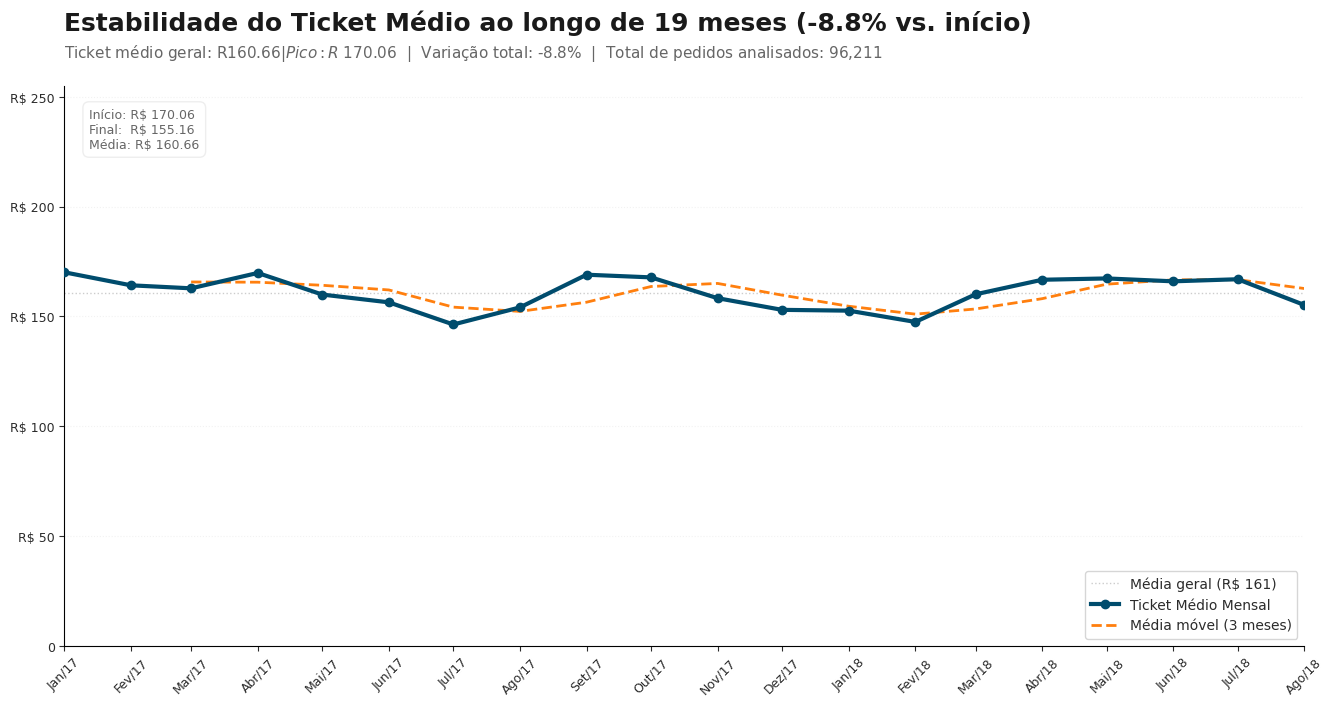

In [122]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import pandas as pd

# --- Preparação dos Dados ---
df_plot = df_kpi2.copy()

if str(df_plot['ano_mes'].dtype) == 'period[M]':
    df_plot['data'] = df_plot['ano_mes'].dt.to_timestamp()
else:
    df_plot['data'] = pd.to_datetime(df_plot['ano_mes'])

df_plot = df_plot[(df_plot['data'] >= data_inicio_ref) & (df_plot['data'] <= data_fim_ref)].copy()
df_plot = df_plot.sort_values('data').reset_index(drop=True)

df_plot['mm3_ticket'] = df_plot['ticket_medio'].rolling(3).mean()

# --- Métricas ---
val_inicial        = df_plot['ticket_medio'].iloc[0]
val_final          = df_plot['ticket_medio'].iloc[-1]
val_pico           = df_plot['ticket_medio'].max()          # ← estava faltando
data_pico          = df_plot.loc[df_plot['ticket_medio'].idxmax(), 'data']
ticket_medio_geral = df_plot['ticket_medio'].mean()
n_meses            = (data_fim_ref.year - data_inicio_ref.year) * 12 + (data_fim_ref.month - data_inicio_ref.month)
variacao_pct       = ((val_final / val_inicial) - 1) * 100
total_pedidos      = df_plot['qtd_pedidos'].sum()

# --- Meses em português ---                                 # ← estava faltando
meses_pt = ['Jan','Fev','Mar','Abr','Mai','Jun',
            'Jul','Ago','Set','Out','Nov','Dez']

# --- Configurações Visuais ---
AZUL_ESCURO, LARANJA, CINZA_TEXTO = '#004c6d', '#ff7f0e', '#1A1A1A'
CINZA_SUB, COR_PICO = '#666666', '#1b4f72'

fig, ax = plt.subplots(figsize=(16, 8), dpi=100)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.yaxis.grid(True, linestyle=':', alpha=0.25, color='#cccccc')

# --- CAIXA DE RESUMO ---
info_box = f"Início: R$ {val_inicial:.2f}\nFinal:  R$ {val_final:.2f}\nMédia: R$ {ticket_medio_geral:.2f}"
ax.text(0.02, 0.96, info_box, transform=ax.transAxes, fontsize=9,
        bbox=dict(facecolor='white', edgecolor='#eeeeee', boxstyle='round,pad=0.5'),
        color=CINZA_SUB, va='top', zorder=10)

# --- LINHA DE MÉDIA GERAL ---
ax.axhline(ticket_medio_geral, color='#aaaaaa', lw=1.0, ls=':', alpha=0.6,
           label=f'Média geral (R$ {ticket_medio_geral:,.0f})', zorder=2)

# --- LINHAS PRINCIPAIS ---
ax.plot(df_plot['data'], df_plot['ticket_medio'], color=AZUL_ESCURO, lw=3,
        marker='o', markersize=6, label='Ticket Médio Mensal', zorder=4)

ax.plot(df_plot['data'], df_plot['mm3_ticket'], color=LARANJA, ls='--', lw=2,
        label='Média móvel (3 meses)', zorder=3)



# --- FORMATAÇÃO DOS EIXOS ---
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(FuncFormatter(
    lambda x, p: f"{meses_pt[mdates.num2date(x).month - 1]}/{str(mdates.num2date(x).year)[2:]}"
))
ax.yaxis.set_major_formatter(FuncFormatter(
    lambda x, p: f'R$ {x:,.0f}' if x > 0 else '0'
))

ax.set_xlim(data_inicio_ref, data_fim_ref)
ax.set_ylim(0, val_pico * 1.5)

plt.xticks(rotation=45, fontsize=9)
plt.yticks(fontsize=9)

# --- TÍTULOS ---
sinal = '+' if variacao_pct >= 0 else ''
ax.text(0, 1.10,
        f'Estabilidade do Ticket Médio ao longo de {n_meses} meses ({sinal}{variacao_pct:.1f}% vs. início)',
        transform=ax.transAxes, fontsize=18, fontweight='bold', color=CINZA_TEXTO, ha='left')

ax.text(0, 1.05,
        f'Ticket médio geral: R$ {ticket_medio_geral:.2f}  |  '
        f'Pico: R$ {val_pico:.2f}  |  Variação total: {sinal}{variacao_pct:.1f}%  |  '
        f'Total de pedidos analisados: {total_pedidos:,.0f}',
        transform=ax.transAxes, fontsize=11, color=CINZA_SUB, ha='left')

ax.legend(loc='lower right', frameon=True, facecolor='white', fontsize=10)
plt.subplots_adjust(top=0.85, bottom=0.15)

plt.show()

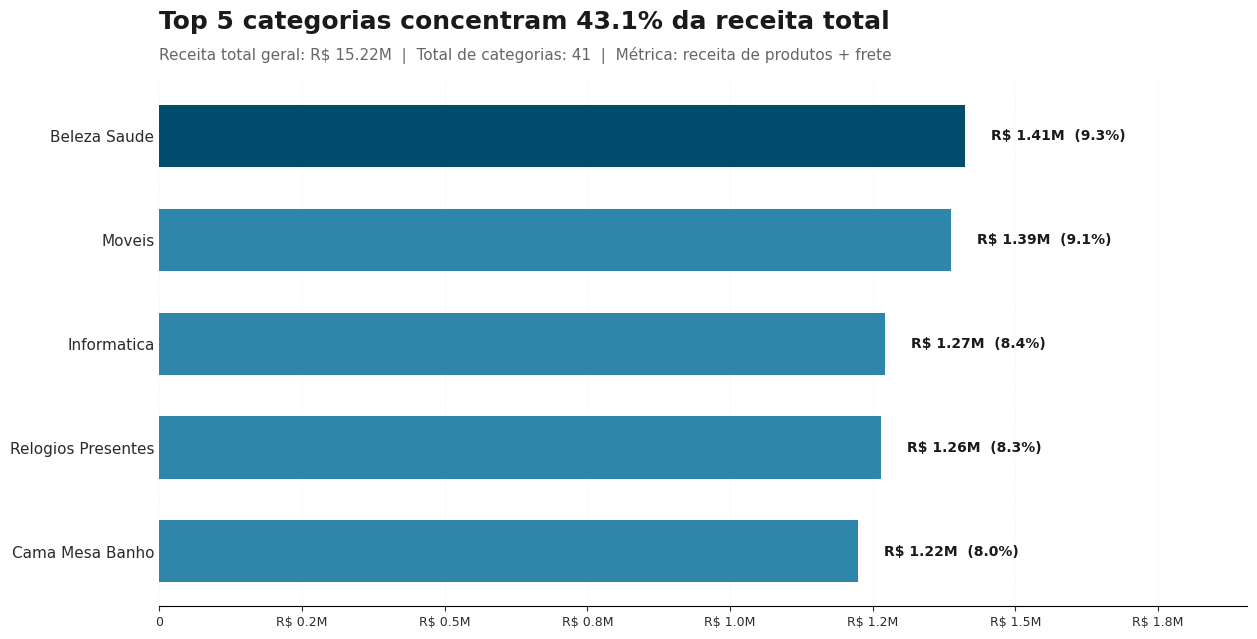

In [123]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import pandas as pd

# --- Preparação dos Dados ---
df_plot3 = df_kpi3.sort_values('receita_total', ascending=False).head(5).copy()
df_plot3 = df_plot3.sort_values('receita_total', ascending=True)  # invertido para barras horizontais

# ✅ Formata os nomes das categorias
df_plot3['categoria_label'] = (
    df_plot3['product_category_clean']
    .str.replace('_', ' ')
    .str.title()
)

# Métricas
receita_total_geral = df_kpi3['receita_total'].sum()
top5_share          = df_plot3['receita_total'].sum() / receita_total_geral * 100
n_categorias        = df_kpi3['product_category_clean'].nunique()

# --- Configurações Visuais ---
AZUL_ESCURO, CINZA_TEXTO = '#004c6d', '#1A1A1A'
CINZA_SUB, AZUL_CLARO    = '#666666', '#2e86ab'

cores = [AZUL_CLARO] * 4 + [AZUL_ESCURO]

fig, ax = plt.subplots(figsize=(16, 7), dpi=100)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.xaxis.grid(True, linestyle=':', alpha=0.25, color='#cccccc')
ax.set_axisbelow(True)

# --- BARRAS HORIZONTAIS ---
bars = ax.barh(
    df_plot3['categoria_label'],  # ✅ atualizado
    df_plot3['receita_total'],
    color=cores,
    height=0.6,
    zorder=3
)

# --- RÓTULOS NAS BARRAS ---
for bar, (_, row) in zip(bars, df_plot3.iterrows()):
    valor  = row['receita_total']
    share  = valor / receita_total_geral * 100
    ax.text(
        valor + receita_total_geral * 0.003,
        bar.get_y() + bar.get_height() / 2,
        f'R\$ {valor/1e6:.2f}M  ({share:.1f}%)',
        va='center', ha='left', fontsize=10,
        color=CINZA_TEXTO, fontweight='bold'
    )

# --- FORMATAÇÃO DOS EIXOS ---
ax.xaxis.set_major_formatter(FuncFormatter(
    lambda x, p: f'R\$ {x/1e6:.1f}M' if x > 0 else '0'
))
ax.tick_params(axis='y', labelsize=11)
ax.tick_params(axis='x', labelsize=9)
ax.yaxis.set_tick_params(length=0)

ax.set_xlim(0, df_plot3['receita_total'].max() * 1.35)

# --- TÍTULOS ---
ax.text(0, 1.10,
        f'Top 5 categorias concentram {top5_share:.1f}% da receita total',
        transform=ax.transAxes, fontsize=18, fontweight='bold',
        color=CINZA_TEXTO, ha='left')

ax.text(0, 1.04,
        f'Receita total geral: R\$ {receita_total_geral/1e6:.2f}M  |  '
        f'Total de categorias: {n_categorias}  |  '
        f'Métrica: receita de produtos + frete',
        transform=ax.transAxes, fontsize=11, color=CINZA_SUB, ha='left')

plt.subplots_adjust(top=0.85, bottom=0.10, left=0.22)  # ✅ left aumentado
plt.show()

In [124]:
import json
df_kpi6_sorted = df_kpi6.sort_values('tempo_medio_entrega')
print(json.dumps([
    {"s": row.customer_state, "t": round(row.tempo_medio_entrega, 1)}
    for _, row in df_kpi6_sorted.iterrows()
]))

[{"s": "SP", "t": 8.3}, {"s": "PR", "t": 11.5}, {"s": "MG", "t": 11.5}, {"s": "DF", "t": 12.5}, {"s": "SC", "t": 14.5}, {"s": "RS", "t": 14.8}, {"s": "RJ", "t": 14.8}, {"s": "GO", "t": 15.2}, {"s": "MS", "t": 15.2}, {"s": "ES", "t": 15.3}, {"s": "TO", "t": 17.2}, {"s": "MT", "t": 17.6}, {"s": "PE", "t": 18.0}, {"s": "RN", "t": 18.8}, {"s": "BA", "t": 18.9}, {"s": "RO", "t": 18.9}, {"s": "PI", "t": 19.0}, {"s": "PB", "t": 20.0}, {"s": "AC", "t": 20.6}, {"s": "CE", "t": 20.8}, {"s": "SE", "t": 21.0}, {"s": "MA", "t": 21.1}, {"s": "PA", "t": 23.3}, {"s": "AL", "t": 24.0}, {"s": "AM", "t": 26.0}, {"s": "AP", "t": 26.7}, {"s": "RR", "t": 29.0}]


In [125]:
print(df_kpi6[['customer_state','tempo_medio_entrega']].sort_values('tempo_medio_entrega').to_string(index=False))

customer_state  tempo_medio_entrega
            SP             8.298094
            PR            11.526711
            MG            11.542188
            DF            12.509135
            SC            14.475183
            RS            14.819237
            RJ            14.848583
            GO            15.150741
            MS            15.191155
            ES            15.331830
            TO            17.226277
            MT            17.593679
            PE            17.965474
            RN            18.824895
            BA            18.866400
            RO            18.913580
            PI            18.993697
            PB            19.953578
            AC            20.637500
            CE            20.817826
            SE            21.029851
            MA            21.117155
            PA            23.316068
            AL            24.040302
            AM            25.986207
            AP            26.731343
            RR            28

In [126]:
df_geo_limpo.to_csv('geo_limpo_carlos.csv', index=False)

In [127]:
df_geo_limpo.to_csv('geo_limpo.csv.gz', index=False, compression='gzip')

In [128]:
df_avaliacoes_limpo.to_csv('carlos_olist_order_reviews_dataset.csv', index=False)

In [129]:
df

,cidade,temperatura,numero_quartos,data_venda,e_novo,comentarios,data_venda_nativa
0,SP,25.5,1,2023-01-01,True,NaN,2023-01-01
1,RJ,30.2,2,2023-01-02,False,NaN,2023-01-02
2,SP,22.8,2,2023-01-03,True,NaN,2023-01-03
3,MG,NaN,3,2023-01-04,False,NaN,2023-01-04
4,BA,28.1,1,2023-01-05,False,NaN,2023-01-05
